In [1]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

pd.set_option('display.max_columns', 500)
pd.set_option('display.max_rows', 500)
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from sklearn import preprocessing, metrics
import optuna
from sklearn.model_selection import StratifiedKFold, KFold, RepeatedKFold, GroupKFold, GridSearchCV, train_test_split, TimeSeriesSplit
import gc
import os

In [2]:
# Source - https://stackoverflow.com/a/20896732
# Posted by pzp, modified by community. See post 'Timeline' for change history
# Retrieved 2026-04-01, License - CC BY-SA 4.0

import sys
print(sys.version)


3.12.7 | packaged by conda-forge | (main, Oct  4 2024, 15:47:54) [MSC v.1941 64 bit (AMD64)]


In [ ]:
# TODO: Benerin salah satu kamar ada yg ga akurat has ac dll diupdate bisa liat di wa
# TODO: inflation_rate, total_capacity_nights dibenerin, pilih pakai lag atau pastiin selalu punya di inference time

In [3]:
# df = pd.read_csv('../data/processed/room_monthly_features_v5.2.csv') 
# df = pd.read_csv('../data/processed/room_monthly_features_v6.csv') # 
# df = pd.read_csv('../data/processed/room_monthly_features_v7.3.csv')
# df = pd.read_csv('../data/processed/room_monthly_features_v7.4.csv')# Best so far
df = pd.read_csv('../data/processed/room_monthly_features_v8.csv')
df.head()

,month_period,id,masterId,propertyId,roomId,numChild,price,commission,range_booking_arrival,num_of_nights,price_per_day,status_confirmed,status_new,subStatus_noShow,subStatus_nonPayment,subStatus_none,subStatus_walkin,title_Honeymoon_decor,title_RO,title_Teman_kim_kasih_breakfast,title_Twin_bed,arrivalTime_16_30,arrivalTime__,groupNote_Room_Only_,custom1_Paid_OTA,custom1_Paid_by_OTA_Auto_Adjusted,referer_Booking_com,refererEditable_Booking_com,channel_booking,apiSource_Booking_com,allowChannelUpdate_all,allowAutoAction_disable,allowAutoAction_enable,allowReview_default,allowCancellation__type_propertyDefault_,cancelTime_2024_08_05T03_15_10Z,year,month,year_month,total_capacity_nights,used_room_nights,leftover_rooms,cal_days_covered,cal_numAvail_mean,cal_numAvail_min,cal_numAvail_max,cal_numAvail_std,cal_numAvail_zero_days,cal_numAvail_low_days,cal_minStay_mean,cal_minStay_max,cal_minStay_restrict_days,cal_maxStay_mean,cal_multiplier_mean,cal_multiplier_max,cal_override_days,cal_soldout_rate,cal_low_avail_rate,cal_restrict_rate,cal_override_rate,prop_latitude,prop_longitude,prop_checkin_start_min,prop_checkin_end_min,prop_checkout_end_min,prop_booking_cutoff_hour,prop_vat_rate,prop_feature_codes_count,prop_group_keywords_count,prop_type_bedAndBreakfast,prop_type_bungalow,prop_type_guesthouse,prop_type_hotel,prop_type_resort,prop_type_villa,prop_country_ID,ch_channel_count,ch_enabled_ratio,ch_publish_ratio,ch_connect_inventory_ratio,ch_connect_limited_ratio,ch_price_per_day_ratio,review_count,avg_review_score,avg_facilities_score,avg_comfort_score,avg_staff_score,avg_value_score,avg_clean_score,avg_location_score,tfidf_beach,tfidf_clean,tfidf_da,tfidf_de,tfidf_der,tfidf_die,tfidf_el,tfidf_en,tfidf_est,tfidf_et,tfidf_friendly,tfidf_good,tfidf_great,tfidf_hotel,tfidf_la,tfidf_le,tfidf_location,tfidf_muy,tfidf_nice,tfidf_place,tfidf_pool,tfidf_que,tfidf_room,tfidf_sehr,tfidf_staff,tfidf_stay,tfidf_super,tfidf_trs,tfidf_un,tfidf_und,qty,room_cfg_qty_raw,room_cfg_min_price,room_cfg_min_stay,room_cfg_max_stay,room_cfg_max_people,room_cfg_max_adult,room_cfg_max_children,room_cfg_tax_percentage,room_cfg_tax_person,room_cfg_rack_rate,room_cfg_cleaning_fee,room_cfg_security_deposit,room_cfg_sell_priority,room_cfg_room_size,room_cfg_block_after_checkout_days,room_cfg_control_priority,room_cfg_include_in_reports,room_cfg_units_count,room_cfg_has_unallocated_unit,room_cfg_feature_count,room_cfg_roomType_bungalow,room_cfg_roomType_double,room_cfg_roomType_family,room_cfg_roomType_quadruple,room_cfg_roomType_single,room_cfg_roomType_triple,room_cfg_roomType_twin,room_cfg_roomType_twindouble,room_cfg_roomType_villa,room_cfg_restrictionStrategy_staythrough,room_cfg_overbookingProtection_property,room_cfg_overbookingProtection_room,room_cfg_unitAllocation_perbooking,room_fc_airport_shuttle,room_fc_air_conditioning,room_fc_baggage_storage,room_fc_balcony,room_fc_bar,room_fc_bathrobe,room_fc_bathroom,room_fc_bath_or_shower,room_fc_bath_shower,room_fc_bath_toilet,room_fc_beach,room_fc_beach_front,room_fc_beach_view,room_fc_bedroom,room_fc_bed_double,room_fc_bed_single,room_fc_bicycle,room_fc_breakfast_included,room_fc_breakfast_in_room,room_fc_breakfast_possible,room_fc_cable,room_fc_car_available,room_fc_cleaning_included,room_fc_cleaning_possible,room_fc_closets_in_room,room_fc_coffee_maker,room_fc_cycling,room_fc_deck_patio_uncovered,room_fc_desk,room_fc_dining_area,room_fc_dining_room_seats,room_fc_garden,room_fc_hair_dryer,room_fc_hangers,room_fc_iron,room_fc_kettle,room_fc_laptop_friendly,room_fc_linens,room_fc_luxory_linen,room_fc_minibar,room_fc_mountain_biking,room_fc_private_bathroom,room_fc_reception_24_hour,room_fc_refrigerator,room_fc_restaurant,room_fc_room_soundproofed,room_fc_safe,room_fc_satellite,room_fc_scuba_or_snorkeling,room_fc_separate_toilet_area,room_fc_shampoo,room_fc_sitting_area,room_fc_tables_and_chairs,room_fc_toiletries,room_fc_towels,room_fc_tv,room_fc_tv_hd_32_plus,room_fc_wakeupcall,room_fc_wifi
0,2023-01,3.718405e+

In [4]:
import pandas as pd
import numpy as np

def create_continuous_calendar_grid(df):
    """
    Forces the dataframe to have a continuous row for every month 
    between the min and max date for every room.
    """
    print("Building continuous calendar grid...")
    df = df.copy()
    
    # 1. Ensure date is datetime
    if 'date' not in df.columns:
        if pd.api.types.is_period_dtype(df['month_period']):
            df['date'] = df['month_period'].dt.to_timestamp()
        else:
            df['date'] = pd.to_datetime(df['month_period'])
            
    # 2. Get global start and end dates
    min_date = df['date'].min()
    max_date = df['date'].max()
    
    # 3. Create a perfect range of all months
    all_months = pd.date_range(start=min_date, end=max_date, freq='MS')
    all_rooms = df['roomId'].unique()
    
    # 4. Create Cartesian product (Every room gets every month)
    grid = pd.MultiIndex.from_product(
        [all_rooms, all_months], 
        names=['roomId', 'date']
    ).to_frame(index=False)
    
    # 5. Merge the real data onto the perfect grid
    full_df = pd.merge(grid, df, on=['roomId', 'date'], how='left')
    
    # 6. Rebuild month_period for the newly created empty rows
    full_df['month_period'] = full_df['date'].dt.to_period('M')
    
    # 7. Forward/Backward fill static categorical features so they aren't NaN
    static_cols = [
        "propertyId", "room_cfg_room_type", "room_cfg_restriction_strategy", 
        "room_cfg_overbooking_protection", "room_cfg_unit_allocation", "room_cfg_tier"
    ]
    for col in static_cols:
        if col in full_df.columns:
            full_df[col] = full_df.groupby('roomId')[col].transform(lambda x: x.ffill().bfill())
            
    full_df = full_df.sort_values(['roomId', 'date']).reset_index(drop=True)
    print(f"Grid built. Expanded from {len(df)} to {len(full_df)} rows to fill chronological gaps.")
    
    return full_df

In [5]:
df['price'] = df['price_per_day'] 
df = df.drop('price_per_day', axis=1)
df['date'] = pd.to_datetime(df['month_period'].astype(str))
df.head()


,month_period,id,masterId,propertyId,roomId,numChild,price,commission,range_booking_arrival,num_of_nights,status_confirmed,status_new,subStatus_noShow,subStatus_nonPayment,subStatus_none,subStatus_walkin,title_Honeymoon_decor,title_RO,title_Teman_kim_kasih_breakfast,title_Twin_bed,arrivalTime_16_30,arrivalTime__,groupNote_Room_Only_,custom1_Paid_OTA,custom1_Paid_by_OTA_Auto_Adjusted,referer_Booking_com,refererEditable_Booking_com,channel_booking,apiSource_Booking_com,allowChannelUpdate_all,allowAutoAction_disable,allowAutoAction_enable,allowReview_default,allowCancellation__type_propertyDefault_,cancelTime_2024_08_05T03_15_10Z,year,month,year_month,total_capacity_nights,used_room_nights,leftover_rooms,cal_days_covered,cal_numAvail_mean,cal_numAvail_min,cal_numAvail_max,cal_numAvail_std,cal_numAvail_zero_days,cal_numAvail_low_days,cal_minStay_mean,cal_minStay_max,cal_minStay_restrict_days,cal_maxStay_mean,cal_multiplier_mean,cal_multiplier_max,cal_override_days,cal_soldout_rate,cal_low_avail_rate,cal_restrict_rate,cal_override_rate,prop_latitude,prop_longitude,prop_checkin_start_min,prop_checkin_end_min,prop_checkout_end_min,prop_booking_cutoff_hour,prop_vat_rate,prop_feature_codes_count,prop_group_keywords_count,prop_type_bedAndBreakfast,prop_type_bungalow,prop_type_guesthouse,prop_type_hotel,prop_type_resort,prop_type_villa,prop_country_ID,ch_channel_count,ch_enabled_ratio,ch_publish_ratio,ch_connect_inventory_ratio,ch_connect_limited_ratio,ch_price_per_day_ratio,review_count,avg_review_score,avg_facilities_score,avg_comfort_score,avg_staff_score,avg_value_score,avg_clean_score,avg_location_score,tfidf_beach,tfidf_clean,tfidf_da,tfidf_de,tfidf_der,tfidf_die,tfidf_el,tfidf_en,tfidf_est,tfidf_et,tfidf_friendly,tfidf_good,tfidf_great,tfidf_hotel,tfidf_la,tfidf_le,tfidf_location,tfidf_muy,tfidf_nice,tfidf_place,tfidf_pool,tfidf_que,tfidf_room,tfidf_sehr,tfidf_staff,tfidf_stay,tfidf_super,tfidf_trs,tfidf_un,tfidf_und,qty,room_cfg_qty_raw,room_cfg_min_price,room_cfg_min_stay,room_cfg_max_stay,room_cfg_max_people,room_cfg_max_adult,room_cfg_max_children,room_cfg_tax_percentage,room_cfg_tax_person,room_cfg_rack_rate,room_cfg_cleaning_fee,room_cfg_security_deposit,room_cfg_sell_priority,room_cfg_room_size,room_cfg_block_after_checkout_days,room_cfg_control_priority,room_cfg_include_in_reports,room_cfg_units_count,room_cfg_has_unallocated_unit,room_cfg_feature_count,room_cfg_roomType_bungalow,room_cfg_roomType_double,room_cfg_roomType_family,room_cfg_roomType_quadruple,room_cfg_roomType_single,room_cfg_roomType_triple,room_cfg_roomType_twin,room_cfg_roomType_twindouble,room_cfg_roomType_villa,room_cfg_restrictionStrategy_staythrough,room_cfg_overbookingProtection_property,room_cfg_overbookingProtection_room,room_cfg_unitAllocation_perbooking,room_fc_airport_shuttle,room_fc_air_conditioning,room_fc_baggage_storage,room_fc_balcony,room_fc_bar,room_fc_bathrobe,room_fc_bathroom,room_fc_bath_or_shower,room_fc_bath_shower,room_fc_bath_toilet,room_fc_beach,room_fc_beach_front,room_fc_beach_view,room_fc_bedroom,room_fc_bed_double,room_fc_bed_single,room_fc_bicycle,room_fc_breakfast_included,room_fc_breakfast_in_room,room_fc_breakfast_possible,room_fc_cable,room_fc_car_available,room_fc_cleaning_included,room_fc_cleaning_possible,room_fc_closets_in_room,room_fc_coffee_maker,room_fc_cycling,room_fc_deck_patio_uncovered,room_fc_desk,room_fc_dining_area,room_fc_dining_room_seats,room_fc_garden,room_fc_hair_dryer,room_fc_hangers,room_fc_iron,room_fc_kettle,room_fc_laptop_friendly,room_fc_linens,room_fc_luxory_linen,room_fc_minibar,room_fc_mountain_biking,room_fc_private_bathroom,room_fc_reception_24_hour,room_fc_refrigerator,room_fc_restaurant,room_fc_room_soundproofed,room_fc_safe,room_fc_satellite,room_fc_scuba_or_snorkeling,room_fc_separate_toilet_area,room_fc_shampoo,room_fc_sitting_area,room_fc_tables_and_chairs,room_fc_toiletries,room_fc_towels,room_fc_tv,room_fc_tv_hd_32_plus,room_fc_wakeupcall,room_fc_wifi,date
0,2023-01,3.718405e+07,5.9002

In [6]:
data = df

In [7]:
import pandas as pd
import numpy as np

# 1. Load the inflation data
inflasi_df = pd.read_csv('../data/raw/inflasi.csv', sep=';')

# 2. Map Indonesian months to numbers
indo_months = {
    'Januari': '01', 'Februari': '02', 'Maret': '03', 'April': '04',
    'Mei': '05', 'Juni': '06', 'Juli': '07', 'Agustus': '08',
    'September': '09', 'Oktober': '10', 'November': '11', 'Desember': '12'
}

# 3. Clean the 'Periode' column and convert to Datetime
# Example: "Maret 2026" -> "2026-03-01"
inflasi_df['month_str'] = inflasi_df['Periode'].apply(lambda x: x.split()[0])
inflasi_df['year_str'] = inflasi_df['Periode'].apply(lambda x: x.split()[1])
inflasi_df['month_num'] = inflasi_df['month_str'].map(indo_months)
inflasi_df['date'] = pd.to_datetime(inflasi_df['year_str'] + '-' + inflasi_df['month_num'] + '-01')

# 4. Clean the 'Data Inflasi' column and convert to Float
# Example: "3.48 %" -> 3.48
inflasi_df['inflation_rate'] = inflasi_df['Data Inflasi'].str.replace(' %', '').astype(float)

# Keep only what we need
inflasi_df = inflasi_df[['date', 'inflation_rate']]

# 5. Merge into your main 'data'
# Assuming your main 'data' already has the 'date' column properly formatted
data = pd.merge(data, inflasi_df, on='date', how='left')

# Forward fill any missing inflation months just in case
data['inflation_rate'] = data['inflation_rate'].ffill().bfill()

In [8]:
df.drop(columns=['date'], inplace=True)

In [9]:

# ==========================================
# 1. INITIAL DATA PREP 
# ==========================================
# 1. Safely handle the PeriodDtype so Pandas doesn't crash
if pd.api.types.is_period_dtype(data['month_period']):
    data['date'] = data['month_period'].dt.to_timestamp()
else:
    data['date'] = pd.to_datetime(data['month_period'])

# 2. Extract year and month for global reference
data['year'] = data['date'].dt.year
data['month'] = data['date'].dt.month

# 3. Sort correctly
data = data.sort_values(["roomId", "date"]).reset_index(drop=True)

# ---------------------------------------------------------
# 🚨 OPTIONAL BUT RECOMMENDED: Run the grid fixer here! 🚨
# data = create_continuous_calendar_grid(data)
# ---------------------------------------------------------

# 4. Fill missing prices (ffill/bfill or interpolate)
data["price"] = data["price"].replace(0, np.nan)
data["price"] = data.groupby("roomId")["price"].transform(lambda x: x.ffill().bfill())

overall_holdout_mape = []
overall_holdout_mae = []
best_params_by_h = {}
trained_models = {}

def safe_mape(y_true, y_pred, eps=1e-6):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.where(np.abs(y_true) < eps, eps, np.abs(y_true))
    return np.mean(np.abs(y_true - y_pred) / denom)

In [10]:
# 1. Define the specific Property ID
target_property = 515268

# 2. Create the masks
# Mask A: Remove everything before August 2024 for this property
mask_pre_aug_2024 = (data['propertyId'] == target_property) & (data['date'] < '2024-08-01')

# Mask B: Remove specific "empty" or outlier months in 2026
# Based on your graph, months 2, 3, 4, 6, 9, 10, 11, 12 in 2026 appear empty/missing
months_to_remove_2026 = [2, 3, 4, 6, 9, 10, 11, 12]
mask_empty_2026 = (
    (data['propertyId'] == target_property) & 
    (data['date'].dt.year == 2026) & 
    (data['date'].dt.month.isin(months_to_remove_2026))
)

# 3. Combine masks and filter
# We use the tilde (~) to keep everything EXCEPT these two conditions
data = data[~(mask_pre_aug_2024 | mask_empty_2026)].reset_index(drop=True)

print(f"Data cleaned for Room {target_property}. Remaining rows: {len(data)}")

Data cleaned for Room 515268. Remaining rows: 1388


In [11]:
# for room_id, subset in data.groupby("roomId"):
#     subset = subset.copy()
#     subset["month_period"] = pd.to_datetime(subset["month_period"])
#     subset = subset.sort_values("month_period")

#     plt.figure(figsize=(12,5))
#     plt.plot(subset["month_period"], subset["price"], marker='o')

#     plt.xticks(rotation=45)
#     plt.tight_layout()

#     plt.xlabel("Month")
#     plt.ylabel("Price")
#     plt.title(f"Room {room_id} Price Over Time")

#     plt.show()

In [12]:
data = data[data["propertyId"] != 194837]
data = data[data["propertyId"] != 194842]

In [15]:
import pandas as pd
import numpy as np

def advanced_hybrid_fe_direct(data, h=1):
    """
    Feature engineering for Direct Multi-Step Forecasting (YoY Target).
    Includes Vectorized Smart Fallback Anchors + MACRO INFLATION.
    """
    df = data.copy()
    
    # 1. Sort correctly to prevent data leakage in shifts
    df = df.sort_values(['roomId', 'month_period']).reset_index(drop=True)

    # ======================
    # TIME & SEASON FEATURES
    # ======================
    df['date'] = pd.to_datetime(df['month_period'].astype(str))
    df['month'] = df['date'].dt.month
    df['quarter'] = df['date'].dt.quarter
    df['year'] = df['date'].dt.year
    
    season_map = {1:0, 2:0, 11:0, 3:1, 4:1, 5:1, 6:1, 10:1, 7:2, 8:2, 9:2, 12:3}
    df['season_strength'] = df['month'].map(season_map)

    # Peak Lombok/Gili season
    df['is_peak_season'] = df['month'].isin([7, 8, 12]).astype(int)
    
    eid_months = {
        2022: 5, 2023: 4, 2024: 4, 2025: 3, 2026: 3, 2027: 3 
    }
    df['is_eid_month'] = df.apply(lambda row: 1 if eid_months.get(row['year']) == row['month'] else 0, axis=1)
    df['is_major_holiday_month'] = ((df['month'] == 12) | (df['is_eid_month'] == 1)).astype(int)

    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

    # ======================
    # DYNAMIC LAGS
    # ======================
    base_lag = h 
    
    lags_to_create = list(set([
        base_lag, 
        base_lag + 1, 
        base_lag + 2, 
        base_lag + 5, 
        base_lag + 11, 
        base_lag + 12,
        12, 24, 36  
    ]))
    
    for lag in lags_to_create:
        df[f'price_lag_{lag}'] = df.groupby('roomId')['price'].shift(lag)
        
        # Shift inflation just like we shift price!
        if 'inflation_rate' in df.columns:
            # We don't group by roomId for inflation since it's global, 
            # but doing it guarantees row alignment per room
            df[f'inflation_lag_{lag}'] = df.groupby('roomId')['inflation_rate'].shift(lag)

    # ======================
    # SMART DYNAMIC ANCHOR + MACRO INFLATION
    # ======================
    df['dynamic_anchor_price'] = df['price_lag_12']
    df['anchor_age_months'] = 12
    
    if 'inflation_rate' in df.columns:
        df['dynamic_anchor_inflation'] = df['inflation_lag_12']

    # Fallback 1: 2 Years Ago (24 months)
    mask_24 = df['dynamic_anchor_price'].isna() & df['price_lag_24'].notna()
    df.loc[mask_24, 'dynamic_anchor_price'] = df.loc[mask_24, 'price_lag_24']
    df.loc[mask_24, 'anchor_age_months'] = 24
    if 'inflation_rate' in df.columns:
        df.loc[mask_24, 'dynamic_anchor_inflation'] = df.loc[mask_24, 'inflation_lag_24']

    # Fallback 2: 3 Years Ago (36 months)
    mask_36 = df['dynamic_anchor_price'].isna() & df['price_lag_36'].notna()
    df.loc[mask_36, 'dynamic_anchor_price'] = df.loc[mask_36, 'price_lag_36']
    df.loc[mask_36, 'anchor_age_months'] = 36
    if 'inflation_rate' in df.columns:
        df.loc[mask_36, 'dynamic_anchor_inflation'] = df.loc[mask_36, 'inflation_lag_36']

    # Fallback 3: Most Recent Known Price (base_lag)
    mask_base = df['dynamic_anchor_price'].isna() & df[f'price_lag_{base_lag}'].notna()
    df.loc[mask_base, 'dynamic_anchor_price'] = df.loc[mask_base, f'price_lag_{base_lag}']
    df.loc[mask_base, 'anchor_age_months'] = base_lag
    if 'inflation_rate' in df.columns:
        df.loc[mask_base, 'dynamic_anchor_inflation'] = df.loc[mask_base, f'inflation_lag_{base_lag}']

    df['is_fallback_anchor'] = (df['anchor_age_months'] != 12).astype(int)

    # 🚨 NEW MACRO FEATURE: The change in inflation between the old anchor and right now
    if 'inflation_rate' in df.columns:
        # Current known inflation (at base_lag) minus inflation when the anchor was recorded
        df['inflation_diff_since_anchor'] = df[f'inflation_lag_{base_lag}'] - df['dynamic_anchor_inflation']
        
        # Absolute inflation at the time of prediction origin
        df['current_known_inflation'] = df[f'inflation_lag_{base_lag}']

    # ======================
    # ROLLING FEATURES (Anchored to base_lag)
    # ======================
    windows = [3, 6, 12]
    for w in windows:
        df[f'price_roll_mean_{w}'] = df.groupby('roomId')[f'price_lag_{base_lag}'].transform(
            lambda x: x.rolling(w, min_periods=1).mean()
        )
        df[f'price_roll_std_{w}'] = df.groupby('roomId')[f'price_lag_{base_lag}'].transform(
            lambda x: x.rolling(w, min_periods=2).std()
        )
        df[f'price_roll_max_{w}'] = df.groupby('roomId')[f'price_lag_{base_lag}'].transform(
            lambda x: x.rolling(w, min_periods=1).max()
        )
        df[f'price_roll_min_{w}'] = df.groupby('roomId')[f'price_lag_{base_lag}'].transform(
            lambda x: x.rolling(w, min_periods=1).min()
        )

    df['price_diff_1'] = df[f'price_lag_{base_lag}'] - df[f'price_lag_{base_lag + 1}']
    df['price_diff_12'] = df[f'price_lag_{base_lag}'] - df[f'price_lag_{base_lag + 11}']
    
    eps = 1e-5
    df['price_growth_1'] = df['price_diff_1'] / (df[f'price_lag_{base_lag + 1}'] + eps)
    df['price_ema_3'] = df.groupby('roomId')[f'price_lag_{base_lag}'].transform(
        lambda x: x.ewm(span=3, adjust=False).mean()
    )

    df['price_base_vs_anchor'] = df[f'price_lag_{base_lag}'] / (df['dynamic_anchor_price'] + eps)

    # ======================
    # BEHAVIOR & OCCUPANCY
    # ======================
    leaky_numerical_cols = [
        'used_room_nights', 'leftover_rooms', 'range_booking_arrival', 
        'num_of_nights', 'commission', 'numChild'
    ]
    leaky_numerical_cols = [c for c in leaky_numerical_cols if c in df.columns]

    for col in leaky_numerical_cols:
        for rl in [0, 1, 11]:
            actual_lag = base_lag + rl
            df[f'{col}_lag_{actual_lag}'] = df.groupby('roomId')[col].shift(actual_lag)
        
        df[f'{col}_roll_mean_3'] = df.groupby('roomId')[f'{col}_lag_{base_lag}'].transform(
            lambda x: x.rolling(3, min_periods=1).mean()
        )

    if f'used_room_nights_lag_{base_lag}' in df.columns and f'used_room_nights_lag_{base_lag+1}' in df.columns:
        df['occupancy_trend'] = df[f'used_room_nights_lag_{base_lag}'] - df[f'used_room_nights_lag_{base_lag+1}']

    # ======================
    # INTERACTION FEATURES 
    # ======================
    df['price_to_mean_ratio'] = df[f'price_lag_{base_lag}'] / (df['price_roll_mean_12'] + eps)
    
    if 'propertyId' in df.columns:
        prop_mean = df.groupby('propertyId')[f'price_lag_{base_lag}'].transform('mean')
        prop_std = df.groupby('propertyId')[f'price_lag_{base_lag}'].transform('std')
        df['price_vs_property_avg'] = df[f'price_lag_{base_lag}'] / (prop_mean + eps)
        df['price_zscore_property'] = (df[f'price_lag_{base_lag}'] - prop_mean) / (prop_std + eps)

    if f'used_room_nights_lag_{base_lag}' in df.columns:
        df['occupancy_price_interaction'] = df[f'used_room_nights_lag_{base_lag}'] * df[f'price_lag_{base_lag}']

    if 'price_roll_mean_3' in df.columns and 'price_roll_mean_12' in df.columns:
        df['trend_3_vs_12'] = df['price_roll_mean_3'] / (df['price_roll_mean_12'] + eps)

    if 'price_roll_mean_6' in df.columns:
        df['trend_slope'] = df[f'price_lag_{base_lag}'] - df['price_roll_mean_6']
        df['price_vs_roll_mean_6'] = df[f'price_lag_{base_lag}'] / (df['price_roll_mean_6'] + eps)
        df['price_cv_6'] = df['price_roll_std_6'] / (df['price_roll_mean_6'] + eps)
        
        median_std = df['price_roll_std_6'].median()
        if pd.notna(median_std):
            df['is_volatile_room'] = (df['price_roll_std_6'] > median_std).astype(int)
        
        df['is_spike'] = (
            abs(df[f'price_lag_{base_lag}'] - df['price_roll_mean_6']) > 2 * df['price_roll_std_6']
        ).astype(int)

    df['season_price_interaction'] = df['season_strength'] * df[f'price_lag_{base_lag}']
    df['peak_price_interaction'] = df['is_peak_season'] * df[f'price_lag_{base_lag}']

    if 'occupancy_trend' in df.columns:
        df['occupancy_season_interaction'] = df['occupancy_trend'] * df['is_peak_season']

    # ======================
    # EXTRA LONG-HORIZON SIGNAL
    # ======================
    if f'price_lag_{base_lag}' in df.columns and f'price_lag_{base_lag+12}' in df.columns:
        df['price_yoy_historical'] = df[f'price_lag_{base_lag}'] / (df[f'price_lag_{base_lag+12}'] + eps)

    if 'price_roll_mean_12' in df.columns:
        df['price_vs_trend_12'] = df[f'price_lag_{base_lag}'] / (df['price_roll_mean_12'] + eps)

    if 'price_roll_mean_3' in df.columns and 'price_roll_mean_12' in df.columns:
        df['trend_strength'] = df['price_roll_mean_3'] - df['price_roll_mean_12']

    df['month_price_interaction'] = df['month'] * df[f'price_lag_{base_lag}']
    df['month_sin_price'] = df['month_sin'] * df[f'price_lag_{base_lag}']
    df['month_cos_price'] = df['month_cos'] * df[f'price_lag_{base_lag}']

    # ======================
    # SHIFT REMAINING CATEGORICALS / UNKNOWN COLUMNS
    # ======================
    safe_current_month_cols = {
        'id', 'propertyId', 'roomId', 'month_period', 'date', 
        'month', 'quarter', 'year', 'season_strength', 
        'is_peak_season', 'is_eid_month', 'is_major_holiday_month', 
        'total_capacity_nights', 'price', 'month_sin', 'month_cos',
        'dynamic_anchor_price', 'anchor_age_months', 'is_fallback_anchor',
        'inflation_rate', 'dynamic_anchor_inflation', 'inflation_diff_since_anchor', 'current_known_inflation'
    }
    
    all_raw_cols = set(data.columns)
    other_leaky_cols = list(all_raw_cols - safe_current_month_cols - set(leaky_numerical_cols))
    
    for col in other_leaky_cols:
        df[f'{col}_lag_{base_lag}'] = df.groupby('roomId')[col].shift(base_lag)

    cols_to_drop = list(set(leaky_numerical_cols) | set(other_leaky_cols))
    if 'id' in df.columns:
        cols_to_drop.append('id')
    
    df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

    # ======================
    # ROBUSTNESS (REDUCE OVERFITTING)
    # ======================
    for col in ['price_to_mean_ratio', 'price_vs_property_avg', 'price_vs_roll_mean_6', 'price_base_vs_anchor', 'price_yoy_historical']:
        if col in df.columns:
            df[col] = df[col].clip(0, 5)

    for col in ['price_roll_std_6', 'price_roll_std_12']:
        if col in df.columns:
            df[f'log_{col}'] = np.log1p(df[col])

    return df

In [13]:
data = data[data["propertyId"] != 194837]
data = data[data["propertyId"] != 194842]
# data = data[data["propertyId"] != 243134]

In [162]:
import numpy as np
import pandas as pd

def predict_for_room_month(
    test_data,
    x_test_full,
    trained_models,
    room_id,
    year,
    month,
    full_data,       # <-- Added master data to fetch last year's price
    model_index=1
):
    # Filter test data mask
    mask = (
        (test_data["roomId"] == room_id) &
        (test_data["year"] == year) &
        (test_data["month"] == month)
    )
    
    # Select features
    X_selected = x_test_full[mask]
    
    if len(X_selected) == 0:
        return np.array([]) # No data to predict
    
    # -------------------------------------------------------------
    # FETCH YoY ANCHOR (Price from exactly 12 months ago)
    # -------------------------------------------------------------
    # We look in the full_data for the same room, year-1, and same month
    hist_mask = (
        (full_data["roomId"] == room_id) & 
        (full_data["year"] == year - 1) & 
        (full_data["month"] == month)
    )
    hist_data = full_data[hist_mask]
    
    # If for some reason last year's data is missing, we need a fallback. 
    # Here we fallback to the last known price in the test set if necessary.
    if not hist_data.empty:
        baseline_selected = hist_data["price"].values[0]
    else:
        # Fallback: Just take the most recent price available for this room
        fallback_mask = (full_data["roomId"] == room_id) & (full_data["price"].notna())
        baseline_selected = full_data[fallback_mask]["price"].values[-1] if not full_data[fallback_mask].empty else 1.0

    # -------------------------------------------------------------
    # INFERENCE & RECONSTRUCTION
    # -------------------------------------------------------------
    # Predict diff (Model now predicts log(price_t) - log(price_{t-12}))
    pred_diff = trained_models[model_index].predict(X_selected)
    
    # Reconstruct final prediction from the YoY anchor
    final_preds = np.expm1(
        np.log1p(baseline_selected) + pred_diff
    )
    
    return final_preds
import gc
import numpy as np
import pandas as pd
import lightgbm as lgb
import optuna
from sklearn import metrics
from sklearn.model_selection import TimeSeriesSplit

optuna.logging.set_verbosity(optuna.logging.WARNING)

# ==========================================
# 1. INITIAL DATA PREP (Assuming 'data' has 'year' and 'month')
# ==========================================
data = data.sort_values(["roomId", "month_period"]).reset_index(drop=True)

data["price"] = data["price"].replace(0, np.nan)
data["price"] = data.groupby("roomId")["price"].transform(lambda x: x.ffill().bfill())

# Ensure date/year/month exist in global data for the inference function
# data['date'] = pd.to_datetime(data['month_period'])
# 1. Safely handle the PeriodDtype so Pandas doesn't crash
if pd.api.types.is_period_dtype(data['month_period']):
    data['date'] = data['month_period'].dt.to_timestamp()
else:
    data['date'] = pd.to_datetime(data['month_period'])
data['year'] = data['date'].dt.year
data['month'] = data['date'].dt.month

overall_holdout_mape = []
overall_holdout_mae = []
best_params_by_h = {}
trained_models = {}

def safe_mape(y_true, y_pred, eps=1e-6):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.where(np.abs(y_true) < eps, eps, np.abs(y_true))
    return np.mean(np.abs(y_true - y_pred) / denom)

# ==========================================
# 2. 12-HORIZON LOOP 
# ==========================================
# Add this right before the 12-Horizon Loop starts
all_holdout_results = []
for h in range(1, 13):
    print(f"\n{'='*70}")
    print(f"Training LightGBM + Optuna for Horizon {h} (Month {h})")
    print(f"{'='*70}")

    step_data = advanced_hybrid_fe_direct(data, h=h)
    
    # -------------------------------------------------------------
    # FORCE THE YoY ANCHOR
    # -------------------------------------------------------------
    # Regardless of horizon h, we want to predict the YoY difference.
    # Therefore, the anchor is ALWAYS 12 months ago.
    anchor_col = "dynamic_anchor_price"
    
    # Ensure the anchor actually exists in step_data before dropping NAs
    if anchor_col not in step_data.columns:
        step_data[anchor_col] = step_data.groupby('roomId')['price'].shift(12)

    step_data = step_data.dropna(subset=[anchor_col, "price"]).reset_index(drop=True)

    train_data = step_data[step_data["date"] < "2025-01-01"].copy()
    test_data = step_data[step_data["date"] >= "2025-01-01"].copy()

    train_data = train_data.sort_values(["date", "roomId"]).reset_index(drop=True)
    test_data = test_data.sort_values(["date", "roomId"]).reset_index(drop=True)

    if len(train_data) < 60:
        print(f"Skip step {h}: not enough train rows ({len(train_data)}).")
        continue

    # -------------------------------------------------------------
    # NEW TARGET: YoY Log-Diff
    # -------------------------------------------------------------
    y_train = np.log1p(train_data["price"]) - np.log1p(train_data[anchor_col])

    # Drop target columns and the dynamic h-lags to prevent leakage
    cols_to_drop = [
        "price", "log_price", "target_diff", "target_pct",
        "date", "month_period", f"log_price_lag_{h}", "log_price_lag_12", "id"
    ]
    x_train_full = train_data.drop(columns=[c for c in cols_to_drop if c in train_data.columns], errors="ignore")
    x_test_full = test_data.drop(columns=[c for c in cols_to_drop if c in test_data.columns], errors="ignore")

    cat_cols = [
        "roomId", "propertyId", "room_cfg_room_type",
        "room_cfg_restriction_strategy", "room_cfg_overbooking_protection",
        "room_cfg_unit_allocation", "room_cfg_tier",
    ]
    for c in cat_cols:
        if c in x_train_full.columns:
            x_train_full[c] = x_train_full[c].astype("category")
        if c in x_test_full.columns:
            x_test_full[c] = x_test_full[c].astype("category")

    good_lgbm_dtypes = ["number", "category", "bool"]
    x_train_full = x_train_full.select_dtypes(include=good_lgbm_dtypes).copy()
    x_test_full = x_test_full.reindex(columns=x_train_full.columns).copy()

    cat_cols_present = [c for c in cat_cols if c in x_train_full.columns]
    for c in cat_cols_present:
        x_test_full[c] = pd.Categorical(x_test_full[c], categories=x_train_full[c].cat.categories)
    
    if x_train_full.shape[1] == 0:
        print(f"Skip step {h}: no usable feature columns.")
        continue

    # Set up baselines for reconstruction
    actual_test_prices = test_data["price"].values
    baseline_test_prices = test_data[anchor_col].values
    baseline_train_prices = train_data[anchor_col].values

    n_splits = 4 if len(train_data) >= 180 else 3 if len(train_data) >= 100 else 2
    tscv = TimeSeriesSplit(n_splits=n_splits)

    def objective(trial):
        num_boost_round = trial.suggest_int("num_boost_round", 100, 800)
        params = {
            "objective": "regression",
            "metric": "rmse",
            "boosting_type": "gbdt",
            "verbosity": -1,
            "random_state": 222,
            "linear_tree": True,

            "drop_rate": trial.suggest_float("drop_rate", 0.05, 0.2),
            "skip_drop": trial.suggest_float("skip_drop", 0.5, 0.9),
            "max_drop": trial.suggest_int("max_drop", 10, 50),
            "num_leaves": trial.suggest_int("num_leaves", 10, 40),
            "max_depth": trial.suggest_int("max_depth", 3, 8),
            "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 5, 30),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
            "feature_fraction": trial.suggest_float("feature_fraction", 0.6, 1.0),
            "bagging_fraction": trial.suggest_float("bagging_fraction", 0.6, 1.0),
            "bagging_freq": trial.suggest_int("bagging_freq", 1, 10),
            "min_child_samples": trial.suggest_int("min_child_samples", 20, 150),
            
            "alpha": trial.suggest_float("alpha", 0.7, 0.95),
            "lambda_l1": trial.suggest_float("lambda_l1", 1e-6, 20.0, log=True),
            "lambda_l2": trial.suggest_float("lambda_l2", 1e-6, 20.0, log=True),
            "min_sum_hessian_in_leaf": trial.suggest_float("min_sum_hessian_in_leaf", 1e-3, 10.0, log=True),
            "min_gain_to_split": trial.suggest_float("min_gain_to_split", 1e-8, 0.3, log=True),
            "max_bin": trial.suggest_int("max_bin", 63, 255),
            "path_smooth": trial.suggest_float("path_smooth", 0.0, 20.0),
            "feature_fraction_bynode": trial.suggest_float("feature_fraction_bynode", 0.5, 1.0),
            "extra_trees": trial.suggest_categorical("extra_trees", [False, True]),
        }

        fold_mae = []

        for fold_i, (train_idx, valid_idx) in enumerate(tscv.split(x_train_full)):
            X_trn = x_train_full.iloc[train_idx]
            X_val = x_train_full.iloc[valid_idx]
            y_trn = y_train.iloc[train_idx]
            y_val = y_train.iloc[valid_idx]

            dtrain = lgb.Dataset(X_trn, label=y_trn, categorical_feature=cat_cols_present, free_raw_data=False)
            dvalid = lgb.Dataset(X_val, label=y_val, categorical_feature=cat_cols_present, reference=dtrain, free_raw_data=False)

            model = lgb.train(
                params=params,
                train_set=dtrain,
                num_boost_round=num_boost_round,
                valid_sets=[dvalid],
                callbacks=[
                    lgb.early_stopping(stopping_rounds=80, verbose=False),
                    lgb.log_evaluation(period=0),
                ],
            )
            
            # Predict the YoY Diff
            pred_val_diff = model.predict(X_val, num_iteration=model.best_iteration)
            
            # Reconstruct using the YoY anchor (t-12)
            base_val = train_data[anchor_col].iloc[valid_idx].values
            pred_val_price = np.expm1(np.log1p(base_val) + pred_val_diff)

            true_val_price = train_data["price"].iloc[valid_idx].values
            mae_val = metrics.mean_absolute_error(true_val_price, pred_val_price)
            fold_mae.append(mae_val)
            # feat_imp = pd.DataFrame({
            #     "feature": model.feature_name(),
            #     "importance": model.feature_importance()
            # }).sort_values(by="importance", ascending=False)

            # print(feat_imp.head(100))

            trial.report(float(np.mean(fold_mae)), fold_i)
            if trial.should_prune():
                raise optuna.TrialPruned()
                
            del X_trn, X_val, y_trn, y_val, dtrain, dvalid, model
            gc.collect()

        return float(np.mean(fold_mae))

    study = optuna.create_study(
        direction="minimize",
        sampler=optuna.samplers.TPESampler(seed=222),
        pruner=optuna.pruners.MedianPruner(n_warmup_steps=1),
    )
    study.optimize(objective, n_trials=1, show_progress_bar=False) # Bump this up to 15+ later!

    best_params = study.best_params.copy()
    best_rounds = int(best_params.pop("num_boost_round"))
    best_params.update({
        "objective": "regression",
        "metric": "rmse",
        "boosting_type": "gbdt",
        "verbosity": -1,
        "random_state": 222,
    })

    dtrain_full = lgb.Dataset(
        x_train_full,
        label=y_train,
        categorical_feature=cat_cols_present,
        free_raw_data=False
    )
    final_model = lgb.train(
        params=best_params,
        train_set=dtrain_full,
        num_boost_round=best_rounds,
    )

    best_params_by_h[h] = {"num_boost_round": best_rounds, **best_params}
    trained_models[h] = final_model

    # Train metrics
    pred_train_diff = final_model.predict(x_train_full)
    final_train_predictions = np.expm1(np.log1p(baseline_train_prices) + pred_train_diff)
    train_mape = safe_mape(train_data["price"].values, final_train_predictions)
    train_mae = metrics.mean_absolute_error(train_data["price"].values, final_train_predictions)

    print(f"Step {h} best CV MAE: {study.best_value:,.2f}")
    print(f"  - Train MAPE: {train_mape:.4f} ({train_mape*100:.2f}%) | Train MAE: Rp {train_mae:,.2f}")

    # Holdout metrics
    # Holdout metrics
    if len(x_test_full) > 0:
        pred_test_diff = final_model.predict(x_test_full)
        final_test_predictions = np.expm1(np.log1p(baseline_test_prices) + pred_test_diff)

        test_mape = safe_mape(actual_test_prices, final_test_predictions)
        test_mae = metrics.mean_absolute_error(actual_test_prices, final_test_predictions)

        print(f"  - Holdout MAPE: {test_mape:.4f} ({test_mape*100:.2f}%) | Holdout MAE: Rp {test_mae:,.2f}")

        overall_holdout_mape.append(test_mape)
        overall_holdout_mae.append(test_mae)
        
        # 🚨 NEW: Save the granular row-level predictions for this horizon
        step_results = pd.DataFrame({
            "roomId": test_data["roomId"].values,
            "propertyId": test_data["propertyId"].values if "propertyId" in test_data.columns else "Unknown",
            "horizon": h,
            "actual_price": actual_test_prices,
            "predicted_price": final_test_predictions
        })
        all_holdout_results.append(step_results)
    else:
        print("  - No holdout rows for this step.")

# ==========================================
# 3. FINAL SUMMARY & GRANULAR METRICS
# ==========================================
print("\n" + "*"*70)
print("FINAL OVERALL LIGHTGBM METRICS (Mean of 12 Horizons)")
print("*"*70)

# Load your mapping data (Make sure to change the path to where your file actually is!)
roomqty_df = pd.read_csv('../data/raw/room_qty.csv') # <-- UPDATE PATH HERE

if overall_holdout_mape and overall_holdout_mae:
    mean_12_mape = float(np.mean(overall_holdout_mape))
    mean_12_mae = float(np.mean(overall_holdout_mae))
    print(f"Mean Holdout MAPE across horizons: {mean_12_mape:.4f} ({mean_12_mape*100:.2f}%)")
    print(f"Mean Holdout MAE across horizons : Rp {mean_12_mae:,.2f}")
    
    # -------------------------------------------------------------
    # CALCULATE METRICS PER ROOM AND PROPERTY
    # -------------------------------------------------------------
    results_df = pd.concat(all_holdout_results, ignore_index=True)
    
    # Calculate row-level errors
    results_df["abs_error"] = np.abs(results_df["actual_price"] - results_df["predicted_price"])
    results_df["pct_error"] = results_df["abs_error"] / np.where(results_df["actual_price"] == 0, 1e-6, results_df["actual_price"])
    
    # Group by Room ID
    room_metrics = results_df.groupby("roomId").agg(
        mae=("abs_error", "mean"),
        mape=("pct_error", "mean"),
        prediction_count=("actual_price", "count")
    ).reset_index()
    room_metrics["mape"] = room_metrics["mape"] * 100 
    
    # 🚨 MERGE ROOM AND PROPERTY NAMES 🚨
    room_mapping = roomqty_df[['room_id', 'room_name', 'property_name']].drop_duplicates()
    room_metrics = room_metrics.merge(room_mapping, left_on='roomId', right_on='room_id', how='left')
    
    # Reorder columns for a cleaner display
    room_cols = ['roomId', 'room_name', 'property_name', 'mape', 'mae', 'prediction_count']
    room_metrics = room_metrics[[c for c in room_cols if c in room_metrics.columns]]
    
    # Group by Property ID
    prop_metrics = results_df.groupby("propertyId").agg(
        mae=("abs_error", "mean"),
        mape=("pct_error", "mean"),
        prediction_count=("actual_price", "count")
    ).reset_index()
    prop_metrics["mape"] = prop_metrics["mape"] * 100
    
    # 🚨 MERGE PROPERTY NAMES 🚨
    prop_mapping = roomqty_df[['property_id', 'property_name']].drop_duplicates()
    prop_metrics = prop_metrics.merge(prop_mapping, left_on='propertyId', right_on='property_id', how='left')
    
    # Reorder columns for a cleaner display
    prop_cols = ['propertyId', 'property_name', 'mape', 'mae', 'prediction_count']
    prop_metrics = prop_metrics[[c for c in prop_cols if c in prop_metrics.columns]]
    
    # -------------------------------------------------------------
    # DISPLAY TABLES
    # -------------------------------------------------------------
    print("\n" + "="*80)
    print("📈 TOP 10 WORST PERFORMING ROOMS (Highest MAPE)")
    print("="*80)
    display(room_metrics.sort_values("mape", ascending=False).head(10).style.format({
        'mae': 'Rp {:,.0f}',
        'mape': '{:.2f}%'
    }).hide(axis="index"))
    
    print("\n" + "="*80)
    print("🏢 METRICS BY PROPERTY")
    print("="*80)
    display(prop_metrics.sort_values("mape", ascending=False).style.format({
        'mae': 'Rp {:,.0f}',
        'mape': '{:.2f}%'
    }).hide(axis="index"))

else:
    print("No holdout metrics were computed.")
print("*"*70 + "\n")


Training LightGBM + Optuna for Horizon 1 (Month 1)
Step 1 best CV MAE: 104,594.04
  - Train MAPE: 0.0894 (8.94%) | Train MAE: Rp 56,688.90
  - Holdout MAPE: 0.1724 (17.24%) | Holdout MAE: Rp 110,735.76

Training LightGBM + Optuna for Horizon 2 (Month 2)
Step 2 best CV MAE: 143,430.70
  - Train MAPE: 0.0951 (9.51%) | Train MAE: Rp 60,547.48
  - Holdout MAPE: 0.1864 (18.64%) | Holdout MAE: Rp 121,903.35

Training LightGBM + Optuna for Horizon 3 (Month 3)
Step 3 best CV MAE: 160,891.24
  - Train MAPE: 0.0974 (9.74%) | Train MAE: Rp 62,103.54
  - Holdout MAPE: 0.1950 (19.50%) | Holdout MAE: Rp 125,105.61

Training LightGBM + Optuna for Horizon 4 (Month 4)
Step 4 best CV MAE: 166,541.33
  - Train MAPE: 0.0972 (9.72%) | Train MAE: Rp 62,713.61
  - Holdout MAPE: 0.2063 (20.63%) | Holdout MAE: Rp 130,085.52

Training LightGBM + Optuna for Horizon 5 (Month 5)
Step 5 best CV MAE: 113,368.51
  - Train MAPE: 0.1007 (10.07%) | Train MAE: Rp 65,283.89
  - Holdout MAPE: 0.2140 (21.40%) | Holdout MAE

roomId,room_name,property_name,mape,mae,prediction_count
515268,Bungalow Deluxe,Sari Gili Bungalow,55.98%,"Rp 258,519",156
512299,Luxury Deluxe Room,Sari Gili Bungalow,45.31%,"Rp 346,353",183
350455,Double Room with Terrace,Abams Gili Air,40.78%,"Rp 153,690",192
370150,"Hot Water, Quadruple Room 5-6",Bougenville Homestay,36.96%,"Rp 152,732",144
388812,Deluxe Double Room,Salili Bungalow,33.28%,"Rp 301,296",204
462631,Superior Single,Pandan Bungalow,30.02%,"Rp 92,108",240
354680,King Room with Balcony,Mantra Gili,27.87%,"Rp 213,050",216
354681,King Room with Pool View,Mantra Gili,27.64%,"Rp 201,334",204
370148,Double Room 2 & 4,Bougenville Homestay,27.41%,"Rp 70,753",192
354683,Deluxe Double or Twin Room with Balcony,Mantra Gili,25.26%,"Rp 175,177",240



🏢 METRICS BY PROPERTY


propertyId,property_name,mape,mae,prediction_count
158986,Abams Gili Air,40.78%,"Rp 153,690",192
243134,Sari Gili Bungalow,33.47%,"Rp 190,829",681
161014,Mantra Gili,25.94%,"Rp 186,874",912
169082,Bougenville Homestay,23.48%,"Rp 79,211",860
179195,Salili Bungalow,20.55%,"Rp 168,114",958
158990,Pandan Bungalow,19.66%,"Rp 93,695",1245
163277,Kaluku Gili Resort,13.13%,"Rp 173,974",840
193394,Bintang Darmawan Villa (BDV),12.90%,"Rp 71,985",540
174792,Shefa Private Villa,12.45%,"Rp 159,083",252
201589,Bungalow No 7,10.68%,"Rp 47,203",588


**********************************************************************



In [ ]:
import gc
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn import metrics

# ==============================
# CONFIG
# ==============================
exclude_last_n_months_2025 = 4  # 2 => exclude 2025-11 and 2025-12

if exclude_last_n_months_2025 <= 0:
    exclude_start_date = pd.Timestamp("2026-01-01")
else:
    m = 13 - int(exclude_last_n_months_2025)  # 2 -> 11
    m = max(1, min(12, m))
    exclude_start_date = pd.Timestamp(f"2026-{m:02d}-01")

holdout_end_date = pd.Timestamp("2027-01-01")
anchor_col = "dynamic_anchor_price"

print(f"Training cutoff: date < {exclude_start_date.date()} (excluded tail: {exclude_start_date.date()} to 2025-12-31)")

def safe_mape_local(y_true, y_pred, eps=1e-6):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.where(np.abs(y_true) < eps, eps, np.abs(y_true))
    return np.mean(np.abs(y_true - y_pred) / denom)

# ==============================
# PRODUCTION RETRAIN
# ==============================
full_production_data = data.copy()
full_production_data = full_production_data.sort_values(["roomId", "month_period"]).reset_index(drop=True)

if "date" not in full_production_data.columns:
    full_production_data["date"] = pd.to_datetime(full_production_data["month_period"], errors="coerce")
else:
    full_production_data["date"] = pd.to_datetime(full_production_data["date"], errors="coerce")

final_production_models = {}
production_tail_eval = []      # horizon-level summary
production_tail_rows = []      # row-level predictions for room/property metrics

for h in range(1, 13):
    if h not in best_params_by_h:
        print(f"[H{h}] Skip: best_params_by_h[{h}] not found.")
        continue

    print(f"\n{'='*70}")
    print(f"Production retrain for horizon {h}")
    print(f"{'='*70}")

    # 1) Build horizon-specific features
    prod_step_data = advanced_hybrid_fe_direct(full_production_data, h=h).copy()

    # 2) Ensure anchor exists
    if anchor_col not in prod_step_data.columns:
        prod_step_data[anchor_col] = prod_step_data.groupby("roomId")["price"].shift(12)

    # Keep valid rows only
    prod_step_data = prod_step_data.dropna(subset=[anchor_col, "price", "date"]).reset_index(drop=True)

    # 3) Train split for production fit (exclude last N months of 2025)
    train_prod = prod_step_data[prod_step_data["date"] < exclude_start_date].copy()

    # Optional: evaluate on excluded tail
    eval_tail = prod_step_data[
        (prod_step_data["date"] >= exclude_start_date) &
        (prod_step_data["date"] < holdout_end_date)
    ].copy()

    if len(train_prod) < 60:
        print(f"[H{h}] Skip: not enough production train rows ({len(train_prod)}).")
        continue

    # 4) Target
    y_prod = np.log1p(train_prod["price"]) - np.log1p(train_prod[anchor_col])

    # 5) Feature prep
    cols_to_drop_prod = [
        "price", "log_price", "target_diff", "target_pct",
        "date", "month_period", f"log_price_lag_{h}", "log_price_lag_12", "id"
    ]
    X_prod = train_prod.drop(columns=[c for c in cols_to_drop_prod if c in train_prod.columns], errors="ignore")

    cat_cols = [
        "roomId", "propertyId",
        "room_cfg_room_type", "room_cfg_restriction_strategy",
        "room_cfg_overbooking_protection", "room_cfg_unit_allocation", "room_cfg_tier"
    ]

    for c in cat_cols:
        if c in X_prod.columns:
            X_prod[c] = X_prod[c].astype("category")

    good_lgbm_dtypes = ["number", "category", "bool"]
    X_prod = X_prod.select_dtypes(include=good_lgbm_dtypes).copy()

    cat_cols_present_prod = [c for c in cat_cols if c in X_prod.columns]

    if X_prod.shape[1] == 0:
        print(f"[H{h}] Skip: no usable columns after dtype filtering.")
        continue

    # 6) Reuse best params (copy so dict is not mutated)
    params_h = best_params_by_h[h].copy()
    rounds_h = int(params_h.pop("num_boost_round"))

    dtrain_prod = lgb.Dataset(
        X_prod,
        label=y_prod,
        categorical_feature=cat_cols_present_prod,
        free_raw_data=False
    )

    final_model = lgb.train(
        params=params_h,
        train_set=dtrain_prod,
        num_boost_round=rounds_h
    )

    final_production_models[h] = final_model
    print(f"[H{h}] Trained with {len(train_prod)} rows, {X_prod.shape[1]} features, rounds={rounds_h}")

    # 7) Optional tail eval (excluded months)
    if len(eval_tail) > 0:
        X_tail = eval_tail.drop(columns=[c for c in cols_to_drop_prod if c in eval_tail.columns], errors="ignore")
        X_tail = X_tail.reindex(columns=X_prod.columns).copy()

        for c in cat_cols_present_prod:
            if c in X_tail.columns:
                X_tail[c] = pd.Categorical(X_tail[c], categories=X_prod[c].cat.categories)

        pred_tail_diff = final_model.predict(X_tail)
        pred_tail_price = np.expm1(np.log1p(eval_tail[anchor_col].values) + pred_tail_diff)

        mae_tail = metrics.mean_absolute_error(eval_tail["price"].values, pred_tail_price)
        mape_tail = safe_mape_local(eval_tail["price"].values, pred_tail_price)

        production_tail_eval.append({
            "horizon": h,
            "tail_rows": len(eval_tail),
            "tail_mae": mae_tail,
            "tail_mape": mape_tail
        })

        # Row-level storage for room/property metrics
        rows = pd.DataFrame({
            "horizon": h,
            "roomId": eval_tail["roomId"].values,
            "propertyId": eval_tail["propertyId"].values if "propertyId" in eval_tail.columns else np.nan,
            "actual_price": eval_tail["price"].values,
            "predicted_price": pred_tail_price
        })
        rows["abs_error"] = np.abs(rows["actual_price"] - rows["predicted_price"])
        rows["pct_error"] = rows["abs_error"] / np.where(np.abs(rows["actual_price"]) < 1e-6, 1e-6, np.abs(rows["actual_price"]))
        production_tail_rows.append(rows)

        print(f"[H{h}] Tail Eval MAE: {mae_tail:,.2f} | MAPE: {mape_tail*100:.2f}%")
    else:
        print(f"[H{h}] Tail Eval: no rows in excluded months window.")

    del prod_step_data, train_prod, eval_tail, X_prod, y_prod, dtrain_prod
    gc.collect()

print("\nProduction models ready:", sorted(final_production_models.keys()))

# ==============================
# HORIZON-LEVEL SUMMARY
# ==============================
if len(production_tail_eval) > 0:
    tail_eval_df = pd.DataFrame(production_tail_eval).sort_values("horizon").reset_index(drop=True)
    display(tail_eval_df)

    mean_12_mae = tail_eval_df["tail_mae"].mean()
    mean_12_mape = tail_eval_df["tail_mape"].mean()
    print(f"\nMean tail MAE across horizons: {mean_12_mae:,.2f}")
    print(f"Mean tail MAPE across horizons: {mean_12_mape*100:.2f}%")

# ==============================
# ROW-LEVEL / ROOM / PROPERTY SUMMARY
# ==============================
if len(production_tail_rows) > 0:
    production_results_df = pd.concat(production_tail_rows, ignore_index=True)

    pooled_mae = production_results_df["abs_error"].mean()
    pooled_mape = production_results_df["pct_error"].mean()
    print(f"\nPooled tail MAE (all rows): {pooled_mae:,.2f}")
    print(f"Pooled tail MAPE (all rows): {pooled_mape*100:.2f}%")

    room_metrics = production_results_df.groupby("roomId").agg(
        mae=("abs_error", "mean"),
        mape=("pct_error", "mean"),
        prediction_count=("actual_price", "count")
    ).reset_index()
    room_metrics["mape"] = room_metrics["mape"] * 100

    prop_metrics = production_results_df.groupby("propertyId").agg(
        mae=("abs_error", "mean"),
        mape=("pct_error", "mean"),
        prediction_count=("actual_price", "count")
    ).reset_index()
    prop_metrics["mape"] = prop_metrics["mape"] * 100

    # Optional name mapping (same style as your original training summary)
    try:
        roomqty_df = pd.read_csv("../data/raw/room_qty.csv")

        if {"room_id", "room_name", "property_name"}.issubset(roomqty_df.columns):
            room_map = roomqty_df[["room_id", "room_name", "property_name"]].drop_duplicates()
            room_metrics = room_metrics.merge(room_map, left_on="roomId", right_on="room_id", how="left")
            room_metrics = room_metrics[[c for c in ["roomId", "room_name", "property_name", "mape", "mae", "prediction_count"] if c in room_metrics.columns]]

        if {"property_id", "property_name"}.issubset(roomqty_df.columns):
            prop_map = roomqty_df[["property_id", "property_name"]].drop_duplicates()
            prop_metrics = prop_metrics.merge(prop_map, left_on="propertyId", right_on="property_id", how="left")
            prop_metrics = prop_metrics[[c for c in ["propertyId", "property_name", "mape", "mae", "prediction_count"] if c in prop_metrics.columns]]

    except Exception as e:
        print(f"Room/property name merge skipped: {e}")

    print("\nTop 10 worst rooms by MAPE (tail window):")
    display(room_metrics.sort_values("mape", ascending=False).head(10))

    print("\nProperty metrics (tail window):")
    display(prop_metrics.sort_values("mape", ascending=False))

Training cutoff: date < 2026-09-01 (excluded tail: 2026-09-01 to 2025-12-31)

Production retrain for horizon 1
[H1] Trained with 1147 rows, 295 features, rounds=360
[H1] Tail Eval MAE: 134,980.07 | MAPE: 15.64%

Production retrain for horizon 2
[H2] Trained with 1113 rows, 297 features, rounds=451
[H2] Tail Eval MAE: 103,256.83 | MAPE: 11.69%

Production retrain for horizon 3
[H3] Trained with 1079 rows, 297 features, rounds=409
[H3] Tail Eval MAE: 98,099.71 | MAPE: 10.47%

Production retrain for horizon 4
[H4] Trained with 1045 rows, 297 features, rounds=263
[H4] Tail Eval MAE: 89,066.23 | MAPE: 10.76%

Production retrain for horizon 5
[H5] Trained with 1011 rows, 297 features, rounds=409
[H5] Tail Eval MAE: 121,365.61 | MAPE: 13.52%

Production retrain for horizon 6
[H6] Trained with 978 rows, 297 features, rounds=716
[H6] Tail Eval MAE: 133,029.74 | MAPE: 15.15%

Production retrain for horizon 7
[H7] Trained with 945 rows, 295 features, rounds=660
[H7] Tail Eval MAE: 110,821.66 | MA

,horizon,tail_rows,tail_mae,tail_mape
0,1,28,134980.071522,0.156381
1,2,28,103256.831169,0.116936
2,3,28,98099.713088,0.104718
3,4,28,89066.228394,0.107593
4,5,28,121365.613152,0.135246
5,6,28,133029.741933,0.151471
6,7,28,110821.661190,0.130657
7,8,28,106039.293233,0.127920
8,9,28,110956.061841,0.141131
9,10,28,97955.162251,0.113667



Mean tail MAE across horizons: 112,468.47
Mean tail MAPE across horizons: 13.06%

Pooled tail MAE (all rows): 112,468.47
Pooled tail MAPE (all rows): 13.06%

Top 10 worst rooms by MAPE (tail window):


,roomId,room_name,property_name,mape,mae,prediction_count
8,388812,Deluxe Double Room,Salili Bungalow,33.569776,339893.982773,12
6,388810,Bungalow Garden View,Salili Bungalow,29.237664,264304.047340,24
11,462632,Deluxe Room,Pandan Bungalow,27.852873,151205.726284,24
0,350455,Double Room with Terrace,Abams Gili Air,24.859238,142070.546160,12
4,359142,Deluxe Pool View,Kaluku Gili Resort,13.105049,135785.165240,48
10,431071,Superior Double Room,Bungalow No 7,12.431312,81221.248100,12
12,462634,Wooden Deluxe Bungalow,Pandan Bungalow,10.904868,97116.808041,24
13,502851,Deluxe Bungalow,Pandan Bungalow,9.611457,61349.132071,36
1,350464,Superior Bungalow,Pandan Bungalow,7.315672,41910.436675,24
2,359135,Deluxe Garden View,Kaluku Gili Resort,7.217783,88130.353183,36



Property metrics (tail window):


,propertyId,property_name,mape,mae,prediction_count
0,158986,Abams Gili Air,24.859238,142070.546160,12
4,179195,Salili Bungalow,24.641568,238914.366921,48
1,158990,Pandan Bungalow,13.442355,84945.926468,108
2,163277,Kaluku Gili Resort,9.291595,107464.809285,120
5,201589,Bungalow No 7,7.601201,42691.038938,36
3,174792,Shefa Private Villa,5.489536,84154.585658,12


In [ ]:
full_production_data = full_production_data.sort_values(["roomId", "date"]).copy()
full_production_data.groupby("roomId")["price"].shift(12).tail(20)

378    9.392129e+05
379    8.799657e+05
380    1.291667e+06
381    1.278525e+06
382    1.331374e+06
383    1.085729e+06
384    8.042879e+05
385    1.005706e+06
386    8.416147e+05
387    9.433917e+05
388    9.809470e+05
389    1.213207e+06
390    1.222580e+06
391    1.257685e+06
392    1.539437e+06
393    1.538561e+06
394    1.496727e+06
395    1.245103e+06
396    1.306463e+06
397    1.344097e+06
Name: price, dtype: float64

In [175]:
full_production_data[(full_production_data["roomId"] == 359142) & (full_production_data["month_period"] == "2027-01")]

,month_period,id,masterId,propertyId,roomId,numChild,price,commission,range_booking_arrival,num_of_nights,status_confirmed,status_new,subStatus_noShow,subStatus_nonPayment,subStatus_none,subStatus_walkin,title_Honeymoon_decor,title_RO,title_Teman_kim_kasih_breakfast,title_Twin_bed,arrivalTime_16_30,arrivalTime__,groupNote_Room_Only_,custom1_Paid_OTA,custom1_Paid_by_OTA_Auto_Adjusted,referer_Booking_com,refererEditable_Booking_com,channel_booking,apiSource_Booking_com,allowChannelUpdate_all,allowAutoAction_disable,allowAutoAction_enable,allowReview_default,allowCancellation__type_propertyDefault_,cancelTime_2024_08_05T03_15_10Z,year,month,year_month,total_capacity_nights,used_room_nights,leftover_rooms,cal_days_covered,cal_numAvail_mean,cal_numAvail_min,cal_numAvail_max,cal_numAvail_std,cal_numAvail_zero_days,cal_numAvail_low_days,cal_minStay_mean,cal_minStay_max,cal_minStay_restrict_days,cal_maxStay_mean,cal_multiplier_mean,cal_multiplier_max,cal_override_days,cal_soldout_rate,cal_low_avail_rate,cal_restrict_rate,cal_override_rate,prop_latitude,prop_longitude,prop_checkin_start_min,prop_checkin_end_min,prop_checkout_end_min,prop_booking_cutoff_hour,prop_vat_rate,prop_feature_codes_count,prop_group_keywords_count,prop_type_bedAndBreakfast,prop_type_bungalow,prop_type_guesthouse,prop_type_hotel,prop_type_resort,prop_type_villa,prop_country_ID,ch_channel_count,ch_enabled_ratio,ch_publish_ratio,ch_connect_inventory_ratio,ch_connect_limited_ratio,ch_price_per_day_ratio,review_count,avg_review_score,avg_facilities_score,avg_comfort_score,avg_staff_score,avg_value_score,avg_clean_score,avg_location_score,tfidf_beach,tfidf_clean,tfidf_da,tfidf_de,tfidf_der,tfidf_die,tfidf_el,tfidf_en,tfidf_est,tfidf_et,tfidf_friendly,tfidf_good,tfidf_great,tfidf_hotel,tfidf_la,tfidf_le,tfidf_location,tfidf_muy,tfidf_nice,tfidf_place,tfidf_pool,tfidf_que,tfidf_room,tfidf_sehr,tfidf_staff,tfidf_stay,tfidf_super,tfidf_trs,tfidf_un,tfidf_und,qty,room_cfg_qty_raw,room_cfg_min_price,room_cfg_min_stay,room_cfg_max_stay,room_cfg_max_people,room_cfg_max_adult,room_cfg_max_children,room_cfg_tax_percentage,room_cfg_tax_person,room_cfg_rack_rate,room_cfg_cleaning_fee,room_cfg_security_deposit,room_cfg_sell_priority,room_cfg_room_size,room_cfg_block_after_checkout_days,room_cfg_control_priority,room_cfg_include_in_reports,room_cfg_units_count,room_cfg_has_unallocated_unit,room_cfg_feature_count,room_cfg_roomType_bungalow,room_cfg_roomType_double,room_cfg_roomType_family,room_cfg_roomType_quadruple,room_cfg_roomType_single,room_cfg_roomType_triple,room_cfg_roomType_twin,room_cfg_roomType_twindouble,room_cfg_roomType_villa,room_cfg_restrictionStrategy_staythrough,room_cfg_overbookingProtection_property,room_cfg_overbookingProtection_room,room_cfg_unitAllocation_perbooking,room_fc_airport_shuttle,room_fc_air_conditioning,room_fc_baggage_storage,room_fc_balcony,room_fc_bar,room_fc_bathrobe,room_fc_bathroom,room_fc_bath_or_shower,room_fc_bath_shower,room_fc_bath_toilet,room_fc_beach,room_fc_beach_front,room_fc_beach_view,room_fc_bedroom,room_fc_bed_double,room_fc_bed_single,room_fc_bicycle,room_fc_breakfast_included,room_fc_breakfast_in_room,room_fc_breakfast_possible,room_fc_cable,room_fc_car_available,room_fc_cleaning_included,room_fc_cleaning_possible,room_fc_closets_in_room,room_fc_coffee_maker,room_fc_cycling,room_fc_deck_patio_uncovered,room_fc_desk,room_fc_dining_area,room_fc_dining_room_seats,room_fc_garden,room_fc_hair_dryer,room_fc_hangers,room_fc_iron,room_fc_kettle,room_fc_laptop_friendly,room_fc_linens,room_fc_luxory_linen,room_fc_minibar,room_fc_mountain_biking,room_fc_private_bathroom,room_fc_reception_24_hour,room_fc_refrigerator,room_fc_restaurant,room_fc_room_soundproofed,room_fc_safe,room_fc_satellite,room_fc_scuba_or_snorkeling,room_fc_separate_toilet_area,room_fc_shampoo,room_fc_sitting_area,room_fc_tables_and_chairs,room_fc_toiletries,room_fc_towels,room_fc_tv,room_fc_tv_hd_32_plus,room_fc_wakeupcall,room_fc_wifi,date,inflation_rate,dynamic_anchor

In [213]:
import joblib

anchor_col = "dynamic_anchor_price"

# filt = (full_production_data["roomId"] == 359142) & (full_production_data["month_period"] >= "2025-01") & (full_production_data["month_period"] <= "2025-12") 


model_path = os.path.join("../models/model_12_bulan_v1", f"model_bulan_1.txt")
booster = lgb.Booster(model_file="../models/model_12_bulan_v1/model_bulan_01.txt")

# meta_path = os.path.join(model_dir, f"model_bulan_{h:02d}.pkl")
meta = joblib.load("../models/model_12_bulan_v1/model_bulan_01.pkl")

full_production_data = data.copy()
full_production_data = full_production_data.sort_values(["roomId", "month_period"]).reset_index(drop=True)

full_production_data = full_production_data[~((full_production_data["roomId"] == 359142) & (full_production_data["month_period"] == "2025-01") & (full_production_data["propertyId"] == 163277))].copy()

new_row = {
    "propertyId": 163277,
    "roomId": 359142,
    "month_period": "2025-01"
}

# convert to DataFrame
new_df = pd.DataFrame([new_row])

# append
full_production_data = pd.concat([full_production_data, new_df], ignore_index=True)
full_production_data = full_production_data.sort_values(["roomId", "month_period"]).reset_index(drop=True)
filt = (full_production_data["roomId"] == 359142) & (full_production_data["month_period"] == "2025-01") & (full_production_data["propertyId"] == 163277)
# print(full_production_data[filt])

if "date" not in full_production_data.columns:
    full_production_data["date"] = pd.to_datetime(full_production_data["month_period"], errors="coerce")
else:
    full_production_data["date"] = pd.to_datetime(full_production_data["date"], errors="coerce")

if anchor_col not in full_production_data.columns:
    full_production_data[anchor_col] = full_production_data.groupby("roomId")["price"].shift(12)

prod_step_data = advanced_hybrid_fe_direct(full_production_data, h=1).copy()

prod_step_data = prod_step_data.loc[filt].copy()
display(prod_step_data)

,month_period,propertyId,roomId,price,year,month,total_capacity_nights,date,inflation_rate,dynamic_anchor_price,quarter,season_strength,is_peak_season,is_eid_month,is_major_holiday_month,month_sin,month_cos,price_lag_1,inflation_lag_1,price_lag_2,inflation_lag_2,price_lag_3,inflation_lag_3,price_lag_36,inflation_lag_36,price_lag_6,inflation_lag_6,price_lag_12,inflation_lag_12,price_lag_13,inflation_lag_13,price_lag_24,inflation_lag_24,anchor_age_months,dynamic_anchor_inflation,is_fallback_anchor,inflation_diff_since_anchor,current_known_inflation,price_roll_mean_3,price_roll_std_3,price_roll_max_3,price_roll_min_3,price_roll_mean_6,price_roll_std_6,price_roll_max_6,price_roll_min_6,price_roll_mean_12,price_roll_std_12,price_roll_max_12,price_roll_min_12,price_diff_1,price_diff_12,price_growth_1,price_ema_3,price_base_vs_anchor,used_room_nights_lag_1,used_room_nights_lag_2,used_room_nights_lag_12,used_room_nights_roll_mean_3,leftover_rooms_lag_1,leftover_rooms_lag_2,leftover_rooms_lag_12,leftover_rooms_roll_mean_3,range_booking_arrival_lag_1,range_booking_arrival_lag_2,range_booking_arrival_lag_12,range_booking_arrival_roll_mean_3,num_of_nights_lag_1,num_of_nights_lag_2,num_of_nights_lag_12,num_of_nights_roll_mean_3,commission_lag_1,commission_lag_2,commission_lag_12,commission_roll_mean_3,numChild_lag_1,numChild_lag_2,numChild_lag_12,numChild_roll_mean_3,occupancy_trend,price_to_mean_ratio,price_vs_property_avg,price_zscore_property,occupancy_price_interaction,trend_3_vs_12,trend_slope,price_vs_roll_mean_6,price_cv_6,is_volatile_room,is_spike,season_price_interaction,peak_price_interaction,occupancy_season_interaction,price_yoy_historical,price_vs_trend_12,trend_strength,month_price_interaction,month_sin_price,month_cos_price,room_cfg_restrictionStrategy_staythrough_lag_1,room_fc_linens_lag_1,room_fc_hangers_lag_1,subStatus_noShow_lag_1,room_fc_bicycle_lag_1,prop_type_resort_lag_1,room_fc_dining_room_seats_lag_1,tfidf_de_lag_1,room_fc_towels_lag_1,cal_override_days_lag_1,room_cfg_max_stay_lag_1,room_cfg_roomType_double_lag_1,room_fc_breakfast_included_lag_1,room_fc_laptop_friendly_lag_1,room_fc_breakfast_in_room_lag_1,room_cfg_roomType_villa_lag_1,room_fc_desk_lag_1,room_fc_deck_patio_uncovered_lag_1,arrivalTime___lag_1,referer_Booking_com_lag_1,prop_type_villa_lag_1,prop_checkin_end_min_lag_1,ch_connect_inventory_ratio_lag_1,room_fc_bed_single_lag_1,cal_soldout_rate_lag_1,year_month_lag_1,room_cfg_units_count_lag_1,room_fc_shampoo_lag_1,room_cfg_roomType_single_lag_1,room_fc_reception_24_hour_lag_1,cal_days_covered_lag_1,room_cfg_room_size_lag_1,room_fc_tv_hd_32_plus_lag_1,room_fc_refrigerator_lag_1,room_cfg_sell_priority_lag_1,room_fc_bar_lag_1,room_fc_luxory_linen_lag_1,tfidf_da_lag_1,tfidf_die_lag_1,groupNote_Room_Only__lag_1,room_fc_satellite_lag_1,avg_location_score_lag_1,room_cfg_block_after_checkout_days_lag_1,avg_value_score_lag_1,room_fc_beach_view_lag_1,tfidf_hotel_lag_1,cal_maxStay_mean_lag_1,cal_low_avail_rate_lag_1,room_fc_sitting_area_lag_1,room_fc_minibar_lag_1,prop_type_hotel_lag_1,tfidf_en_lag_1,room_fc_coffee_maker_lag_1,cal_minStay_max_lag_1,ch_publish_ratio_lag_1,room_fc_cycling_lag_1,prop_booking_cutoff_hour_lag_1,custom1_Paid_by_OTA_Auto_Adjusted_lag_1,room_fc_private_bathroom_lag_1,allowCancellation__type_propertyDefault__lag_1,room_cfg_max_people_lag_1,masterId_lag_1,arrivalTime_16_30_lag_1,allowReview_default_lag_1,cal_restrict_rate_lag_1,room_fc_cable_lag_1,room_fc_closets_in_room_lag_1,room_cfg_overbookingProtection_property_lag_1,room_fc_toiletries_lag_1,room_cfg_min_price_lag_1,room_fc_mountain_biking_lag_1,avg_facilities_score_lag_1,prop_checkout_end_min_lag_1,ch_price_per_day_ratio_lag_1,ch_connect_limited_ratio_lag_1,tfidf_muy_lag_1,room_cfg_max_children_lag_1,room_fc_hair_dryer_lag_1,cal_multiplier_mean_lag_1,tfidf_good_lag_1,title_Twin_bed_lag_1,tfidf_un_lag_1,prop_longitude_lag_1,tfidf_friendly_lag_1,room_fc_bathrobe_lag_1,avg_review_score_lag_1,room_fc_bedroom_lag_1,title_Teman_kim_kasih_br

In [ ]:
import joblib

anchor_col = "dynamic_anchor_price"

# filt = (full_production_data["roomId"] == 359142) & (full_production_data["month_period"] >= "2025-01") & (full_production_data["month_period"] <= "2025-12") 


model_path = os.path.join("../models/model_12_bulan_v1", f"model_bulan_1.txt")
booster = lgb.Booster(model_file="../models/model_12_bulan_v1/model_bulan_01.txt")

# meta_path = os.path.join(model_dir, f"model_bulan_{h:02d}.pkl")
meta = joblib.load("../models/model_12_bulan_v1/model_bulan_01.pkl")

full_production_data = data.copy()
full_production_data = full_production_data.sort_values(["roomId", "month_period"]).reset_index(drop=True)

full_production_data = full_production_data[~((full_production_data["roomId"] == 359142) & (full_production_data["month_period"] == "2025-01"))]

new_row = {
    "propertyId": 163277,
    "roomId": 359142,
    "month_period": "2025-01"
}

# convert to DataFrame
new_df = pd.DataFrame([new_row])

# append
full_production_data = pd.concat([full_production_data, new_df], ignore_index=True)
full_production_data = full_production_data.sort_values(["roomId", "month_period"]).reset_index(drop=True)

filt = (full_production_data["roomId"] == 359142) & (full_production_data["month_period"] == "2025-01")
# print(full_production_data[filt])
if "date" not in full_production_data.columns:
    full_production_data["date"] = pd.to_datetime(full_production_data["month_period"], errors="coerce")
else:
    full_production_data["date"] = pd.to_datetime(full_production_data["date"], errors="coerce")

if anchor_col not in full_production_data.columns:
    full_production_data[anchor_col] = full_production_data.groupby("roomId")["price"].shift(12)

prod_step_data = advanced_hybrid_fe_direct(full_production_data, h=1).copy()

prod_step_data = prod_step_data.loc[filt].copy()
display(prod_step_data)
feature_columns = meta["feature_columns"]
categorical_columns = meta["categorical_columns"]

cols_to_drop_prod = [
    "price", "log_price", "target_diff", "target_pct",
    "date", "month_period", f"log_price_lag_{h}", "log_price_lag_12", "id"
]
X_prod = prod_step_data.drop(columns=[c for c in cols_to_drop_prod if c in prod_step_data.columns])

for c in categorical_columns:
    if c in X_prod.columns:
        X_prod[c] = X_prod[c].astype("category")
        
good_lgbm_dtypes = ["number", "category", "bool"]

X_prod = X_prod.select_dtypes(include=good_lgbm_dtypes).copy()
X_prod = X_prod.reindex(columns=feature_columns).copy()

cat_cols_present_prod = [c for c in categorical_columns if c in X_prod.columns]
y_pred_diff = booster.predict(X_prod, num_iteration=booster.best_iteration)
y_pred_price = np.expm1(np.log1p(prod_step_data[anchor_col].values) + y_pred_diff)

# filt = (full_production_data["roomId"] == 359142) & (full_production_data["month_period"] >= "2025-02") & (full_production_data["month_period"] <= "2026-01") 
y_test_price = prod_step_data["price"].values

# R²
r2 = r2_score(y_test_price, y_pred_price)

# MAE
mae = mean_absolute_error(y_test_price, y_pred_price)

# MAPE (manual)
mape = np.mean(np.abs((y_test_price - y_pred_price) / y_test_price)) * 100

print(f"R2: {r2}")
print(f"MAE: {mae}")
print(f"MAPE: {mape}%")

,month_period,propertyId,roomId,price,year,month,total_capacity_nights,date,inflation_rate,dynamic_anchor_price,quarter,season_strength,is_peak_season,is_eid_month,is_major_holiday_month,month_sin,month_cos,price_lag_1,inflation_lag_1,price_lag_2,inflation_lag_2,price_lag_3,inflation_lag_3,price_lag_36,inflation_lag_36,price_lag_6,inflation_lag_6,price_lag_12,inflation_lag_12,price_lag_13,inflation_lag_13,price_lag_24,inflation_lag_24,anchor_age_months,dynamic_anchor_inflation,is_fallback_anchor,inflation_diff_since_anchor,current_known_inflation,price_roll_mean_3,price_roll_std_3,price_roll_max_3,price_roll_min_3,price_roll_mean_6,price_roll_std_6,price_roll_max_6,price_roll_min_6,price_roll_mean_12,price_roll_std_12,price_roll_max_12,price_roll_min_12,price_diff_1,price_diff_12,price_growth_1,price_ema_3,price_base_vs_anchor,used_room_nights_lag_1,used_room_nights_lag_2,used_room_nights_lag_12,used_room_nights_roll_mean_3,leftover_rooms_lag_1,leftover_rooms_lag_2,leftover_rooms_lag_12,leftover_rooms_roll_mean_3,range_booking_arrival_lag_1,range_booking_arrival_lag_2,range_booking_arrival_lag_12,range_booking_arrival_roll_mean_3,num_of_nights_lag_1,num_of_nights_lag_2,num_of_nights_lag_12,num_of_nights_roll_mean_3,commission_lag_1,commission_lag_2,commission_lag_12,commission_roll_mean_3,numChild_lag_1,numChild_lag_2,numChild_lag_12,numChild_roll_mean_3,occupancy_trend,price_to_mean_ratio,price_vs_property_avg,price_zscore_property,occupancy_price_interaction,trend_3_vs_12,trend_slope,price_vs_roll_mean_6,price_cv_6,is_volatile_room,is_spike,season_price_interaction,peak_price_interaction,occupancy_season_interaction,price_yoy_historical,price_vs_trend_12,trend_strength,month_price_interaction,month_sin_price,month_cos_price,room_cfg_restrictionStrategy_staythrough_lag_1,room_fc_linens_lag_1,room_fc_hangers_lag_1,subStatus_noShow_lag_1,room_fc_bicycle_lag_1,prop_type_resort_lag_1,room_fc_dining_room_seats_lag_1,tfidf_de_lag_1,room_fc_towels_lag_1,cal_override_days_lag_1,room_cfg_max_stay_lag_1,room_cfg_roomType_double_lag_1,room_fc_breakfast_included_lag_1,room_fc_laptop_friendly_lag_1,room_fc_breakfast_in_room_lag_1,room_cfg_roomType_villa_lag_1,room_fc_desk_lag_1,room_fc_deck_patio_uncovered_lag_1,arrivalTime___lag_1,referer_Booking_com_lag_1,prop_type_villa_lag_1,prop_checkin_end_min_lag_1,ch_connect_inventory_ratio_lag_1,room_fc_bed_single_lag_1,cal_soldout_rate_lag_1,year_month_lag_1,room_cfg_units_count_lag_1,room_fc_shampoo_lag_1,room_cfg_roomType_single_lag_1,room_fc_reception_24_hour_lag_1,cal_days_covered_lag_1,room_cfg_room_size_lag_1,room_fc_tv_hd_32_plus_lag_1,room_fc_refrigerator_lag_1,room_cfg_sell_priority_lag_1,room_fc_bar_lag_1,room_fc_luxory_linen_lag_1,tfidf_da_lag_1,tfidf_die_lag_1,groupNote_Room_Only__lag_1,room_fc_satellite_lag_1,avg_location_score_lag_1,room_cfg_block_after_checkout_days_lag_1,avg_value_score_lag_1,room_fc_beach_view_lag_1,tfidf_hotel_lag_1,cal_maxStay_mean_lag_1,cal_low_avail_rate_lag_1,room_fc_sitting_area_lag_1,room_fc_minibar_lag_1,prop_type_hotel_lag_1,tfidf_en_lag_1,room_fc_coffee_maker_lag_1,cal_minStay_max_lag_1,ch_publish_ratio_lag_1,room_fc_cycling_lag_1,prop_booking_cutoff_hour_lag_1,custom1_Paid_by_OTA_Auto_Adjusted_lag_1,room_fc_private_bathroom_lag_1,allowCancellation__type_propertyDefault__lag_1,room_cfg_max_people_lag_1,masterId_lag_1,arrivalTime_16_30_lag_1,allowReview_default_lag_1,cal_restrict_rate_lag_1,room_fc_cable_lag_1,room_fc_closets_in_room_lag_1,room_cfg_overbookingProtection_property_lag_1,room_fc_toiletries_lag_1,room_cfg_min_price_lag_1,room_fc_mountain_biking_lag_1,avg_facilities_score_lag_1,prop_checkout_end_min_lag_1,ch_price_per_day_ratio_lag_1,ch_connect_limited_ratio_lag_1,tfidf_muy_lag_1,room_cfg_max_children_lag_1,room_fc_hair_dryer_lag_1,cal_multiplier_mean_lag_1,tfidf_good_lag_1,title_Twin_bed_lag_1,tfidf_un_lag_1,prop_longitude_lag_1,tfidf_friendly_lag_1,room_fc_bathrobe_lag_1,avg_review_score_lag_1,room_fc_bedroom_lag_1,title_Teman_kim_kasih_br

ValueError: Input contains NaN.

In [222]:
print("y_pred yang nan:", y_pred_price)

y_pred yang nan: [928883.73050785]


In [220]:
print("y_pred yang bukan nan:", y_pred_price)

y_pred yang bukan nan: [930035.19460029]


In [217]:
y_test_price

array([nan])

In [219]:
y_pred_price

array([930035.19460029])

In [201]:
y_pred_price

array([930035.19460029])

In [190]:
y_pred_price

array([1765027.26851827])

In [ ]:
data

In [183]:
y_pred_price

array([1765027.26851827])

In [179]:
X_prod

,propertyId,roomId,year,month,total_capacity_nights,inflation_rate,quarter,season_strength,is_peak_season,is_eid_month,is_major_holiday_month,month_sin,month_cos,price_lag_1,inflation_lag_1,price_lag_2,inflation_lag_2,price_lag_3,inflation_lag_3,price_lag_36,inflation_lag_36,price_lag_6,inflation_lag_6,price_lag_12,inflation_lag_12,price_lag_13,inflation_lag_13,price_lag_24,inflation_lag_24,dynamic_anchor_price,anchor_age_months,dynamic_anchor_inflation,is_fallback_anchor,inflation_diff_since_anchor,current_known_inflation,price_roll_mean_3,price_roll_std_3,price_roll_max_3,price_roll_min_3,price_roll_mean_6,price_roll_std_6,price_roll_max_6,price_roll_min_6,price_roll_mean_12,price_roll_std_12,price_roll_max_12,price_roll_min_12,price_diff_1,price_diff_12,price_growth_1,price_ema_3,price_base_vs_anchor,used_room_nights_lag_1,used_room_nights_lag_2,used_room_nights_lag_12,used_room_nights_roll_mean_3,leftover_rooms_lag_1,leftover_rooms_lag_2,leftover_rooms_lag_12,leftover_rooms_roll_mean_3,range_booking_arrival_lag_1,range_booking_arrival_lag_2,range_booking_arrival_lag_12,range_booking_arrival_roll_mean_3,num_of_nights_lag_1,num_of_nights_lag_2,num_of_nights_lag_12,num_of_nights_roll_mean_3,commission_lag_1,commission_lag_2,commission_lag_12,commission_roll_mean_3,numChild_lag_1,numChild_lag_2,numChild_lag_12,numChild_roll_mean_3,occupancy_trend,price_to_mean_ratio,price_vs_property_avg,price_zscore_property,occupancy_price_interaction,trend_3_vs_12,trend_slope,price_vs_roll_mean_6,price_cv_6,is_volatile_room,is_spike,season_price_interaction,peak_price_interaction,occupancy_season_interaction,price_yoy_historical,price_vs_trend_12,trend_strength,month_price_interaction,month_sin_price,month_cos_price,room_cfg_roomType_family_lag_1,allowReview_default_lag_1,room_fc_wakeupcall_lag_1,cal_minStay_mean_lag_1,room_fc_closets_in_room_lag_1,room_fc_shampoo_lag_1,refererEditable_Booking_com_lag_1,room_fc_beach_lag_1,room_cfg_tax_percentage_lag_1,room_cfg_roomType_quadruple_lag_1,room_fc_separate_toilet_area_lag_1,room_fc_linens_lag_1,cal_days_covered_lag_1,cal_numAvail_zero_days_lag_1,subStatus_walkin_lag_1,avg_facilities_score_lag_1,groupNote_Room_Only__lag_1,room_fc_minibar_lag_1,allowChannelUpdate_all_lag_1,room_cfg_max_stay_lag_1,tfidf_good_lag_1,cal_override_days_lag_1,room_fc_desk_lag_1,review_count_lag_1,room_fc_towels_lag_1,title_RO_lag_1,room_cfg_block_after_checkout_days_lag_1,ch_price_per_day_ratio_lag_1,tfidf_super_lag_1,ch_connect_limited_ratio_lag_1,room_fc_coffee_maker_lag_1,room_cfg_roomType_bungalow_lag_1,prop_country_ID_lag_1,avg_value_score_lag_1,tfidf_pool_lag_1,cal_soldout_rate_lag_1,title_Teman_kim_kasih_breakfast_lag_1,room_cfg_overbookingProtection_property_lag_1,avg_comfort_score_lag_1,referer_Booking_com_lag_1,room_cfg_rack_rate_lag_1,room_fc_satellite_lag_1,room_cfg_roomType_twin_lag_1,prop_checkin_start_min_lag_1,room_cfg_max_people_lag_1,room_fc_dining_area_lag_1,allowCancellation__type_propertyDefault__lag_1,tfidf_que_lag_1,prop_vat_rate_lag_1,avg_location_score_lag_1,ch_channel_count_lag_1,cal_override_rate_lag_1,room_fc_cleaning_included_lag_1,room_fc_baggage_storage_lag_1,room_fc_bedroom_lag_1,tfidf_et_lag_1,tfidf_trs_lag_1,room_fc_breakfast_included_lag_1,room_fc_safe_lag_1,channel_booking_lag_1,room_cfg_sell_priority_lag_1,room_cfg_units_count_lag_1,room_fc_scuba_or_snorkeling_lag_1,room_fc_breakfast_in_room_lag_1,title_Twin_bed_lag_1,room_fc_air_conditioning_lag_1,title_Honeymoon_decor_lag_1,cal_numAvail_std_lag_1,avg_clean_score_lag_1,room_fc_bath_shower_lag_1,room_fc_laptop_friendly_lag_1,status_confirmed_lag_1,room_cfg_min_price_lag_1,room_fc_toiletries_lag_1,tfidf_muy_lag_1,arrivalTime___lag_1,room_fc_bathrobe_lag_1,tfidf_location_lag_1,room_fc_bathroom_lag_1,room_fc_deck_patio_uncovered_lag_1,room_fc_hair_dryer_lag_1,tfidf_der_lag_1,room_fc_iron_lag_1,tfidf_sehr_lag_1,status_new_lag_1,room_fc_hangers_lag_1,arrivalTime_16_30_lag_1,room_cfg_roomType_triple_lag_1,room_cfg_roomType_single_lag_1,cu

In [177]:
y_pred_price

array([ 930035.19460029,  923415.72840162,  968798.9770117 ,
       1114736.62278971, 1214511.73493341, 1197055.79061705,
       1556424.97756937, 1588059.09483   , 1576278.31478102,
       1258653.21179783, 1056771.58971715, 1291966.6476861 ])

In [171]:
X_prod

,propertyId,roomId,year,month,total_capacity_nights,inflation_rate,quarter,season_strength,is_peak_season,is_eid_month,is_major_holiday_month,month_sin,month_cos,price_lag_1,inflation_lag_1,price_lag_2,inflation_lag_2,price_lag_3,inflation_lag_3,price_lag_36,inflation_lag_36,price_lag_6,inflation_lag_6,price_lag_12,inflation_lag_12,price_lag_13,inflation_lag_13,price_lag_24,inflation_lag_24,dynamic_anchor_price,anchor_age_months,dynamic_anchor_inflation,is_fallback_anchor,inflation_diff_since_anchor,current_known_inflation,price_roll_mean_3,price_roll_std_3,price_roll_max_3,price_roll_min_3,price_roll_mean_6,price_roll_std_6,price_roll_max_6,price_roll_min_6,price_roll_mean_12,price_roll_std_12,price_roll_max_12,price_roll_min_12,price_diff_1,price_diff_12,price_growth_1,price_ema_3,price_base_vs_anchor,used_room_nights_lag_1,used_room_nights_lag_2,used_room_nights_lag_12,used_room_nights_roll_mean_3,leftover_rooms_lag_1,leftover_rooms_lag_2,leftover_rooms_lag_12,leftover_rooms_roll_mean_3,range_booking_arrival_lag_1,range_booking_arrival_lag_2,range_booking_arrival_lag_12,range_booking_arrival_roll_mean_3,num_of_nights_lag_1,num_of_nights_lag_2,num_of_nights_lag_12,num_of_nights_roll_mean_3,commission_lag_1,commission_lag_2,commission_lag_12,commission_roll_mean_3,numChild_lag_1,numChild_lag_2,numChild_lag_12,numChild_roll_mean_3,occupancy_trend,price_to_mean_ratio,price_vs_property_avg,price_zscore_property,occupancy_price_interaction,trend_3_vs_12,trend_slope,price_vs_roll_mean_6,price_cv_6,is_volatile_room,is_spike,season_price_interaction,peak_price_interaction,occupancy_season_interaction,price_yoy_historical,price_vs_trend_12,trend_strength,month_price_interaction,month_sin_price,month_cos_price,room_cfg_roomType_family_lag_1,allowReview_default_lag_1,room_fc_wakeupcall_lag_1,cal_minStay_mean_lag_1,room_fc_closets_in_room_lag_1,room_fc_shampoo_lag_1,refererEditable_Booking_com_lag_1,room_fc_beach_lag_1,room_cfg_tax_percentage_lag_1,room_cfg_roomType_quadruple_lag_1,room_fc_separate_toilet_area_lag_1,room_fc_linens_lag_1,cal_days_covered_lag_1,cal_numAvail_zero_days_lag_1,subStatus_walkin_lag_1,avg_facilities_score_lag_1,groupNote_Room_Only__lag_1,room_fc_minibar_lag_1,allowChannelUpdate_all_lag_1,room_cfg_max_stay_lag_1,tfidf_good_lag_1,cal_override_days_lag_1,room_fc_desk_lag_1,review_count_lag_1,room_fc_towels_lag_1,title_RO_lag_1,room_cfg_block_after_checkout_days_lag_1,ch_price_per_day_ratio_lag_1,tfidf_super_lag_1,ch_connect_limited_ratio_lag_1,room_fc_coffee_maker_lag_1,room_cfg_roomType_bungalow_lag_1,prop_country_ID_lag_1,avg_value_score_lag_1,tfidf_pool_lag_1,cal_soldout_rate_lag_1,title_Teman_kim_kasih_breakfast_lag_1,room_cfg_overbookingProtection_property_lag_1,avg_comfort_score_lag_1,referer_Booking_com_lag_1,room_cfg_rack_rate_lag_1,room_fc_satellite_lag_1,room_cfg_roomType_twin_lag_1,prop_checkin_start_min_lag_1,room_cfg_max_people_lag_1,room_fc_dining_area_lag_1,allowCancellation__type_propertyDefault__lag_1,tfidf_que_lag_1,prop_vat_rate_lag_1,avg_location_score_lag_1,ch_channel_count_lag_1,cal_override_rate_lag_1,room_fc_cleaning_included_lag_1,room_fc_baggage_storage_lag_1,room_fc_bedroom_lag_1,tfidf_et_lag_1,tfidf_trs_lag_1,room_fc_breakfast_included_lag_1,room_fc_safe_lag_1,channel_booking_lag_1,room_cfg_sell_priority_lag_1,room_cfg_units_count_lag_1,room_fc_scuba_or_snorkeling_lag_1,room_fc_breakfast_in_room_lag_1,title_Twin_bed_lag_1,room_fc_air_conditioning_lag_1,title_Honeymoon_decor_lag_1,cal_numAvail_std_lag_1,avg_clean_score_lag_1,room_fc_bath_shower_lag_1,room_fc_laptop_friendly_lag_1,status_confirmed_lag_1,room_cfg_min_price_lag_1,room_fc_toiletries_lag_1,tfidf_muy_lag_1,arrivalTime___lag_1,room_fc_bathrobe_lag_1,tfidf_location_lag_1,room_fc_bathroom_lag_1,room_fc_deck_patio_uncovered_lag_1,room_fc_hair_dryer_lag_1,tfidf_der_lag_1,room_fc_iron_lag_1,tfidf_sehr_lag_1,status_new_lag_1,room_fc_hangers_lag_1,arrivalTime_16_30_lag_1,room_cfg_roomType_triple_lag_1,room_cfg_roomType_single_lag_1,cu

In [160]:
prod_step_data.shape

(12, 299)

In [155]:
import joblib
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

anchor_col = "dynamic_anchor_price"
room_id = 359142
eval_start = pd.Timestamp("2025-01-01")
eval_end = pd.Timestamp("2025-12-01")

full_production_data = data.copy()
full_production_data = full_production_data.sort_values(["roomId", "month_period"]).reset_index(drop=True)

if "date" not in full_production_data.columns:
    full_production_data["date"] = pd.to_datetime(full_production_data["month_period"], errors="coerce")
else:
    full_production_data["date"] = pd.to_datetime(full_production_data["date"], errors="coerce")

if anchor_col not in full_production_data.columns:
    full_production_data[anchor_col] = full_production_data.groupby("roomId")["price"].shift(12)

booster = lgb.Booster(model_file="../models/model_12_bulan_v1/model_bulan_01.txt")
meta = joblib.load("../models/model_12_bulan_v1/model_bulan_01.pkl")

filt = (
    (full_production_data["roomId"] == room_id) &
    (full_production_data["date"] >= eval_start) &
    (full_production_data["date"] <= eval_end)
)

test_data = full_production_data.loc[filt].copy()
test_data = test_data.sort_values(["roomId", "date"]).reset_index(drop=True)

prod_step_data = advanced_hybrid_fe_direct(test_data, h=1).copy()

feature_columns = meta["feature_columns"]
categorical_columns = meta["categorical_columns"]

cols_to_drop_prod = [
    "price", "log_price", "target_diff", "target_pct",
    "date", "month_period", "log_price_lag_1", "log_price_lag_12", "id"
]

X_prod = prod_step_data.drop(
    columns=[c for c in cols_to_drop_prod if c in prod_step_data.columns],
    errors="ignore"
)

for c in categorical_columns:
    if c in X_prod.columns:
        X_prod[c] = X_prod[c].astype("category")

good_lgbm_dtypes = ["number", "category", "bool"]
X_prod = X_prod.select_dtypes(include=good_lgbm_dtypes).copy()
X_prod = X_prod.reindex(columns=feature_columns).copy()

y_pred_diff = booster.predict(X_prod, num_iteration=booster.best_iteration)
y_pred_price = np.expm1(np.log1p(test_data[anchor_col].values) + y_pred_diff)

y_test_price = test_data["price"].values

r2 = r2_score(y_test_price, y_pred_price)
mae = mean_absolute_error(y_test_price, y_pred_price)
rmse = np.sqrt(mean_squared_error(y_test_price, y_pred_price))
mape = np.mean(np.abs((y_test_price - y_pred_price) / np.where(y_test_price == 0, 1e-6, y_test_price))) * 100

print(f"R2: {r2}")
print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print(f"MAPE: {mape}%")

R2: -0.9531994575640801
MAE: 258133.58506426806
RMSE: 305902.7936874063
MAPE: 20.587072390065675%


In [148]:
y_pred_price

array([ 785978.59189248, 1204385.28831228,  942078.32467409,
        988155.18510606,  913662.47743235,  905419.91233731,
       1539551.25044867, 1306169.92498233, 1181705.98013267,
        884324.97141221,  678277.86399346, 1024715.72271573])

In [152]:
y_test_price

array([ 943391.70918367,  980946.98214286, 1213206.67063492,
       1222580.39754098, 1257684.73644958, 1539436.88238095,
       1538560.65447154, 1496726.76838235, 1245102.77941176,
       1306463.19338624, 1344097.11646825, 1024397.8875    ])

In [142]:
y_pred_price

array([936658.45989307])

In [143]:
full_production_data[(full_production_data['month_period'] == "2025-06") & (full_production_data["roomId"] == 359142)]['price']

379    1.257685e+06
Name: price, dtype: float64

In [ ]:
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error

y_pred = np.array([785978.59189248, 1105058.04364641, 883047.765734, 891550.58229866, 936658.45989307])
y_test = np.array([943391.709184, 980946.982143, 1.213207e+06, 1.222580e+06, 1.257685e+06])



R2: -3.0824267388044557
MAE: 252747.87417384004
MAPE: 21.830658262800483%


In [ ]:
pred_tail_diff = final_model.predict(X_tail)
        pred_tail_price = np.expm1(np.log1p(eval_tail[anchor_col].values) + pred_tail_diff)

array([-0.04177768])

ValueError: train and valid dataset categorical_feature do not match.

In [17]:
full_production_data

,month_period,id,masterId,propertyId,roomId,numChild,price,commission,range_booking_arrival,num_of_nights,status_confirmed,status_new,subStatus_noShow,subStatus_nonPayment,subStatus_none,subStatus_walkin,title_Honeymoon_decor,title_RO,title_Teman_kim_kasih_breakfast,title_Twin_bed,arrivalTime_16_30,arrivalTime__,groupNote_Room_Only_,custom1_Paid_OTA,custom1_Paid_by_OTA_Auto_Adjusted,referer_Booking_com,refererEditable_Booking_com,channel_booking,apiSource_Booking_com,allowChannelUpdate_all,allowAutoAction_disable,allowAutoAction_enable,allowReview_default,allowCancellation__type_propertyDefault_,cancelTime_2024_08_05T03_15_10Z,year,month,year_month,total_capacity_nights,used_room_nights,leftover_rooms,cal_days_covered,cal_numAvail_mean,cal_numAvail_min,cal_numAvail_max,cal_numAvail_std,cal_numAvail_zero_days,cal_numAvail_low_days,cal_minStay_mean,cal_minStay_max,cal_minStay_restrict_days,cal_maxStay_mean,cal_multiplier_mean,cal_multiplier_max,cal_override_days,cal_soldout_rate,cal_low_avail_rate,cal_restrict_rate,cal_override_rate,prop_latitude,prop_longitude,prop_checkin_start_min,prop_checkin_end_min,prop_checkout_end_min,prop_booking_cutoff_hour,prop_vat_rate,prop_feature_codes_count,prop_group_keywords_count,prop_type_bedAndBreakfast,prop_type_bungalow,prop_type_guesthouse,prop_type_hotel,prop_type_resort,prop_type_villa,prop_country_ID,ch_channel_count,ch_enabled_ratio,ch_publish_ratio,ch_connect_inventory_ratio,ch_connect_limited_ratio,ch_price_per_day_ratio,review_count,avg_review_score,avg_facilities_score,avg_comfort_score,avg_staff_score,avg_value_score,avg_clean_score,avg_location_score,tfidf_beach,tfidf_clean,tfidf_da,tfidf_de,tfidf_der,tfidf_die,tfidf_el,tfidf_en,tfidf_est,tfidf_et,tfidf_friendly,tfidf_good,tfidf_great,tfidf_hotel,tfidf_la,tfidf_le,tfidf_location,tfidf_muy,tfidf_nice,tfidf_place,tfidf_pool,tfidf_que,tfidf_room,tfidf_sehr,tfidf_staff,tfidf_stay,tfidf_super,tfidf_trs,tfidf_un,tfidf_und,qty,room_cfg_qty_raw,room_cfg_min_price,room_cfg_min_stay,room_cfg_max_stay,room_cfg_max_people,room_cfg_max_adult,room_cfg_max_children,room_cfg_tax_percentage,room_cfg_tax_person,room_cfg_rack_rate,room_cfg_cleaning_fee,room_cfg_security_deposit,room_cfg_sell_priority,room_cfg_room_size,room_cfg_block_after_checkout_days,room_cfg_control_priority,room_cfg_include_in_reports,room_cfg_units_count,room_cfg_has_unallocated_unit,room_cfg_feature_count,room_cfg_roomType_bungalow,room_cfg_roomType_double,room_cfg_roomType_family,room_cfg_roomType_quadruple,room_cfg_roomType_single,room_cfg_roomType_triple,room_cfg_roomType_twin,room_cfg_roomType_twindouble,room_cfg_roomType_villa,room_cfg_restrictionStrategy_staythrough,room_cfg_overbookingProtection_property,room_cfg_overbookingProtection_room,room_cfg_unitAllocation_perbooking,room_fc_airport_shuttle,room_fc_air_conditioning,room_fc_baggage_storage,room_fc_balcony,room_fc_bar,room_fc_bathrobe,room_fc_bathroom,room_fc_bath_or_shower,room_fc_bath_shower,room_fc_bath_toilet,room_fc_beach,room_fc_beach_front,room_fc_beach_view,room_fc_bedroom,room_fc_bed_double,room_fc_bed_single,room_fc_bicycle,room_fc_breakfast_included,room_fc_breakfast_in_room,room_fc_breakfast_possible,room_fc_cable,room_fc_car_available,room_fc_cleaning_included,room_fc_cleaning_possible,room_fc_closets_in_room,room_fc_coffee_maker,room_fc_cycling,room_fc_deck_patio_uncovered,room_fc_desk,room_fc_dining_area,room_fc_dining_room_seats,room_fc_garden,room_fc_hair_dryer,room_fc_hangers,room_fc_iron,room_fc_kettle,room_fc_laptop_friendly,room_fc_linens,room_fc_luxory_linen,room_fc_minibar,room_fc_mountain_biking,room_fc_private_bathroom,room_fc_reception_24_hour,room_fc_refrigerator,room_fc_restaurant,room_fc_room_soundproofed,room_fc_safe,room_fc_satellite,room_fc_scuba_or_snorkeling,room_fc_separate_toilet_area,room_fc_shampoo,room_fc_sitting_area,room_fc_tables_and_chairs,room_fc_toiletries,room_fc_towels,room_fc_tv,room_fc_tv_hd_32_plus,room_fc_wakeupcall,room_fc_wifi,date,inflation_rate
0,2023-01,3.71

In [31]:
import gc
import os
import joblib
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn import metrics

save_dir = "../models/model_12_bulan_v1"
os.makedirs(save_dir, exist_ok=True)

full_production_data = data.copy()
full_production_data = full_production_data.sort_values(["roomId", "month_period"]).reset_index(drop=True)

if "date" not in full_production_data.columns:
    full_production_data["date"] = pd.to_datetime(full_production_data["month_period"], errors="coerce")
else:
    full_production_data["date"] = pd.to_datetime(full_production_data["date"], errors="coerce")

final_production_models = {}
saved_model_paths = []

for h in range(1, 13):
    if h not in best_params_by_h:
        print(f"[H{h}] Skip: best_params_by_h[{h}] not found.")
        continue

    print(f"\n{'='*70}")
    print(f"Final retrain on full data for horizon {h}")
    print(f"{'='*70}")

    prod_step_data = advanced_hybrid_fe_direct(full_production_data, h=h).copy()

    if "dynamic_anchor_price" not in prod_step_data.columns:
        prod_step_data["dynamic_anchor_price"] = prod_step_data.groupby("roomId")["price"].shift(12)

    prod_step_data = prod_step_data.dropna(subset=["dynamic_anchor_price", "price", "date"]).reset_index(drop=True)

    y_prod = np.log1p(prod_step_data["price"]) - np.log1p(prod_step_data["dynamic_anchor_price"])

    cols_to_drop_prod = [
        "price", "log_price", "target_diff", "target_pct",
        "date", "month_period", f"log_price_lag_{h}", "log_price_lag_12", "id"
    ]
    X_prod = prod_step_data.drop(columns=[c for c in cols_to_drop_prod if c in prod_step_data.columns], errors="ignore")

    cat_cols = [
        "roomId", "propertyId",
        "room_cfg_room_type", "room_cfg_restriction_strategy",
        "room_cfg_overbooking_protection", "room_cfg_unit_allocation", "room_cfg_tier"
    ]

    for c in cat_cols:
        if c in X_prod.columns:
            X_prod[c] = X_prod[c].astype("category")

    good_lgbm_dtypes = ["number", "category", "bool"]
    X_prod = X_prod.select_dtypes(include=good_lgbm_dtypes).copy()

    cat_cols_present_prod = [c for c in cat_cols if c in X_prod.columns]

    if X_prod.shape[1] == 0:
        print(f"[H{h}] Skip: no usable columns after dtype filtering.")
        continue

    params_h = best_params_by_h[h].copy()
    rounds_h = int(params_h.pop("num_boost_round"))

    dtrain_prod = lgb.Dataset(
        X_prod,
        label=y_prod,
        categorical_feature=cat_cols_present_prod,
        free_raw_data=False
    )

    final_model = lgb.train(
        params=params_h,
        train_set=dtrain_prod,
        num_boost_round=rounds_h
    )

    final_production_models[h] = final_model

    model_txt_path = os.path.join(save_dir, f"model_bulan_{h:02d}.txt")
    model_pkl_path = os.path.join(save_dir, f"model_bulan_{h:02d}.pkl")

    final_model.save_model(model_txt_path)

    joblib.dump(
        {
            "model": final_model,
            "horizon": h,
            "feature_columns": X_prod.columns.tolist(),
            "categorical_columns": cat_cols_present_prod,
            "params": params_h,
            "num_boost_round": rounds_h,
        },
        model_pkl_path
    )

    saved_model_paths.append((h, model_txt_path, model_pkl_path))
    print(f"[H{h}] Saved: {model_txt_path}")
    print(f"[H{h}] Saved: {model_pkl_path}")

    del prod_step_data, X_prod, y_prod, dtrain_prod
    gc.collect()

print("\nSaved models:")
for h, txt_path, pkl_path in saved_model_paths:
    print(f"H{h}: {txt_path} | {pkl_path}")


Final retrain on full data for horizon 1
[H1] Saved: ../models/model_12_bulan_v1\model_bulan_01.txt
[H1] Saved: ../models/model_12_bulan_v1\model_bulan_01.pkl

Final retrain on full data for horizon 2
[H2] Saved: ../models/model_12_bulan_v1\model_bulan_02.txt
[H2] Saved: ../models/model_12_bulan_v1\model_bulan_02.pkl

Final retrain on full data for horizon 3
[H3] Saved: ../models/model_12_bulan_v1\model_bulan_03.txt
[H3] Saved: ../models/model_12_bulan_v1\model_bulan_03.pkl

Final retrain on full data for horizon 4
[H4] Saved: ../models/model_12_bulan_v1\model_bulan_04.txt
[H4] Saved: ../models/model_12_bulan_v1\model_bulan_04.pkl

Final retrain on full data for horizon 5
[H5] Saved: ../models/model_12_bulan_v1\model_bulan_05.txt
[H5] Saved: ../models/model_12_bulan_v1\model_bulan_05.pkl

Final retrain on full data for horizon 6
[H6] Saved: ../models/model_12_bulan_v1\model_bulan_06.txt
[H6] Saved: ../models/model_12_bulan_v1\model_bulan_06.pkl

Final retrain on full data for horizon 

In [27]:
import gc
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn import metrics

# ==============================
# CONFIG
# ==============================
exclude_last_n_months_2025 = 4  # 2 => exclude 2025-11 and 2025-12

if exclude_last_n_months_2025 <= 0:
    exclude_start_date = pd.Timestamp("2026-01-01")
else:
    m = 13 - int(exclude_last_n_months_2025)  # 2 -> 11
    m = max(1, min(12, m))
    exclude_start_date = pd.Timestamp(f"2026-{m:02d}-01")

holdout_end_date = pd.Timestamp("2027-01-01")
anchor_col = "dynamic_anchor_price"

print(f"Training cutoff: date < {exclude_start_date.date()} (excluded tail: {exclude_start_date.date()} to 2025-12-31)")

def safe_mape_local(y_true, y_pred, eps=1e-6):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.where(np.abs(y_true) < eps, eps, np.abs(y_true))
    return np.mean(np.abs(y_true - y_pred) / denom)

# ==============================
# PRODUCTION RETRAIN & EXACT BASELINE PREP
# ==============================
full_production_data = data.copy()
full_production_data = full_production_data.sort_values(["roomId", "month_period"]).reset_index(drop=True)

if "date" not in full_production_data.columns:
    full_production_data["date"] = pd.to_datetime(full_production_data["month_period"], errors="coerce")
else:
    full_production_data["date"] = pd.to_datetime(full_production_data["date"], errors="coerce")

# 1) Build strict calendar-based lag lookups (Safe against missing months)
base_lookup = full_production_data[['roomId', 'date', 'price']].dropna(subset=['date', 'price']).copy()

# Shift dates forward so we can merge them onto the target dates
lag12 = base_lookup.copy(); lag12['date'] = lag12['date'] + pd.DateOffset(months=12); lag12.rename(columns={'price': 'price_lag_12'}, inplace=True)
lag24 = base_lookup.copy(); lag24['date'] = lag24['date'] + pd.DateOffset(months=24); lag24.rename(columns={'price': 'price_lag_24'}, inplace=True)
lag36 = base_lookup.copy(); lag36['date'] = lag36['date'] + pd.DateOffset(months=36); lag36.rename(columns={'price': 'price_lag_36'}, inplace=True)

final_production_models = {}
production_tail_eval = []      
production_tail_rows = []      

for h in range(1, 13):
    if h not in best_params_by_h:
        print(f"[H{h}] Skip: best_params_by_h[{h}] not found.")
        continue

    print(f"\n{'='*70}")
    print(f"Production retrain for horizon {h}")
    print(f"{'='*70}")

    # Build horizon-specific features
    prod_step_data = advanced_hybrid_fe_direct(full_production_data, h=h).copy()

    # Ensure anchor exists (using exact lookup to be safe)
    if anchor_col not in prod_step_data.columns:
        prod_step_data = prod_step_data.merge(lag12.drop_duplicates(subset=["roomId", "date"]), on=["roomId", "date"], how="left")
        prod_step_data.rename(columns={"price_lag_12": anchor_col}, inplace=True)

    # Keep valid rows only
    prod_step_data = prod_step_data.dropna(subset=[anchor_col, "price", "date"]).reset_index(drop=True)

    # Train split for production fit
    train_prod = prod_step_data[prod_step_data["date"] < exclude_start_date].copy()

    # Optional: evaluate on excluded tail
    eval_tail = prod_step_data[
        (prod_step_data["date"] >= exclude_start_date) &
        (prod_step_data["date"] < holdout_end_date)
    ].copy()

    if len(train_prod) < 60:
        print(f"[H{h}] Skip: not enough production train rows ({len(train_prod)}).")
        continue

    # Target
    y_prod = np.log1p(train_prod["price"]) - np.log1p(train_prod[anchor_col])

    # Feature prep
    cols_to_drop_prod = [
        "price", "log_price", "target_diff", "target_pct",
        "date", "month_period", f"log_price_lag_{h}", "log_price_lag_12", "id",
        "price_lag_12", "price_lag_24", "price_lag_36" 
    ]
    X_prod = train_prod.drop(columns=[c for c in cols_to_drop_prod if c in train_prod.columns], errors="ignore")

    cat_cols = [
        "roomId", "propertyId",
        "room_cfg_room_type", "room_cfg_restriction_strategy",
        "room_cfg_overbooking_protection", "room_cfg_unit_allocation", "room_cfg_tier"
    ]

    for c in cat_cols:
        if c in X_prod.columns:
            X_prod[c] = X_prod[c].astype("category")

    good_lgbm_dtypes = ["number", "category", "bool"]
    X_prod = X_prod.select_dtypes(include=good_lgbm_dtypes).copy()
    cat_cols_present_prod = [c for c in cat_cols if c in X_prod.columns]

    if X_prod.shape[1] == 0:
        print(f"[H{h}] Skip: no usable columns after dtype filtering.")
        continue

    # Reuse best params
    params_h = best_params_by_h[h].copy()
    rounds_h = int(params_h.pop("num_boost_round"))

    dtrain_prod = lgb.Dataset(
        X_prod,
        label=y_prod,
        categorical_feature=cat_cols_present_prod,
        free_raw_data=False
    )

    final_model = lgb.train(
        params=params_h,
        train_set=dtrain_prod,
        num_boost_round=rounds_h
    )

    final_production_models[h] = final_model
    print(f"[H{h}] Trained with {len(train_prod)} rows, {X_prod.shape[1]} features, rounds={rounds_h}")

    # Tail eval (excluded months)
    # 7) Tail eval (excluded months)
    if len(eval_tail) > 0:
        
        # FIX: Drop the columns if feature engineering already generated them to prevent _x/_y suffix errors
        conflict_cols = ["price_lag_12", "price_lag_24", "price_lag_36"]
        eval_tail = eval_tail.drop(columns=[c for c in conflict_cols if c in eval_tail.columns], errors="ignore")

        # 2) RE-ATTACH THE BASELINES HERE safely
        eval_tail = eval_tail.merge(lag12.drop_duplicates(subset=["roomId", "date"]), on=["roomId", "date"], how="left")
        eval_tail = eval_tail.merge(lag24.drop_duplicates(subset=["roomId", "date"]), on=["roomId", "date"], how="left")
        eval_tail = eval_tail.merge(lag36.drop_duplicates(subset=["roomId", "date"]), on=["roomId", "date"], how="left")

        X_tail = eval_tail.drop(columns=[c for c in cols_to_drop_prod if c in eval_tail.columns], errors="ignore")
        X_tail = X_tail.reindex(columns=X_prod.columns).copy()

        for c in cat_cols_present_prod:
            if c in X_tail.columns:
                X_tail[c] = pd.Categorical(X_tail[c], categories=X_prod[c].cat.categories)

        pred_tail_diff = final_model.predict(X_tail)
        pred_tail_price = np.expm1(np.log1p(eval_tail[anchor_col].values) + pred_tail_diff)

        mae_tail = metrics.mean_absolute_error(eval_tail["price"].values, pred_tail_price)
        mape_tail = safe_mape_local(eval_tail["price"].values, pred_tail_price)
        rmse_tail = np.sqrt(metrics.mean_squared_error(eval_tail["price"].values, pred_tail_price))

        # production_tail_eval.append({
        #     "horizon": h,
        #     "tail_rows": len(eval_tail),
        #     "tail_mae": mae_tail,
        #     "tail_mape": mape_tail
        # })
        production_tail_eval.append({
            "horizon": h,
            "tail_rows": len(eval_tail),
            "tail_mae": mae_tail,
            "tail_mape": mape_tail,
            "tail_rmse": rmse_tail
        })

        # Row-level storage for room/property metrics, adding baselines
        rows = pd.DataFrame({
            "horizon": h,
            "roomId": eval_tail["roomId"].values,
            "propertyId": eval_tail["propertyId"].values if "propertyId" in eval_tail.columns else np.nan,
            "actual_price": eval_tail["price"].values,
            "predicted_price": pred_tail_price,
            "price_lag_12": eval_tail["price_lag_12"].values,
            "price_lag_24": eval_tail["price_lag_24"].values,
            "price_lag_36": eval_tail["price_lag_36"].values
        })
        
        
        # Model Errors
        rows["abs_error"] = np.abs(rows["actual_price"] - rows["predicted_price"])
        rows["pct_error"] = rows["abs_error"] / np.where(np.abs(rows["actual_price"]) < 1e-6, 1e-6, np.abs(rows["actual_price"]))
        
        production_tail_rows.append(rows)

        # print(f"[H{h}] Tail Eval MAE: {mae_tail:,.2f} | MAPE: {mape_tail*100:.2f}%")
        print(f"[H{h}] Tail Eval MAE: {mae_tail:,.2f} | MAPE: {mape_tail*100:.2f}% | RMSE: {rmse_tail:,.2f}")
    else:
        print(f"[H{h}] Tail Eval: no rows in excluded months window.")

    del prod_step_data, train_prod, eval_tail, X_prod, y_prod, dtrain_prod
    gc.collect()

print("\nProduction models ready:", sorted(final_production_models.keys()))

# ==============================
# HORIZON-LEVEL SUMMARY
# ==============================
if len(production_tail_eval) > 0:
    tail_eval_df = pd.DataFrame(production_tail_eval).sort_values("horizon").reset_index(drop=True)
    display(tail_eval_df)

    mean_12_mae = tail_eval_df["tail_mae"].mean()
    mean_12_mape = tail_eval_df["tail_mape"].mean()
    print(f"\nMean tail MAE across horizons: {mean_12_mae:,.2f}")
    print(f"Mean tail MAPE across horizons: {mean_12_mape*100:.2f}%")
    mean_12_rmse = tail_eval_df["tail_rmse"].mean()
    print(f"Mean tail RMSE across horizons: {mean_12_rmse:,.2f}")
    
# ==============================
# ROW-LEVEL / ROOM + PROPERTY & BASELINE SUMMARY
# ==============================
if len(production_tail_rows) > 0:
    production_results_df = pd.concat(production_tail_rows, ignore_index=True)

    # Calculate baseline errors directly on the pooled dataframe
    for lag in [12, 24, 36]:
        lag_col = f"price_lag_{lag}"
        production_results_df[f"abs_error_{lag}m_base"] = np.abs(production_results_df["actual_price"] - production_results_df[lag_col])
        denom = np.where(np.abs(production_results_df["actual_price"]) < 1e-6, 1e-6, np.abs(production_results_df["actual_price"]))
        production_results_df[f"pct_error_{lag}m_base"] = production_results_df[f"abs_error_{lag}m_base"] / denom

    print(f"\n--- POOLED OVERALL ERRORS (All {len(production_results_df)} Rows) ---")
    print(f"Model Pooled MAE:  {production_results_df['abs_error'].mean():,.2f}")
    print(f"Model Pooled MAPE: {production_results_df['pct_error'].mean()*100:.2f}%\n")
    
    # 3) Print overall metrics for the historical baselines
    for lag in [12, 24, 36]:
        mae_val = production_results_df[f"abs_error_{lag}m_base"].mean()
        mape_val = production_results_df[f"pct_error_{lag}m_base"].mean() * 100
        print(f"Base {lag//12}-Year MAE:  {mae_val:,.2f}")
        print(f"Base {lag//12}-Year MAPE: {mape_val:.2f}%\n")

    # Joint Room & Property Level aggregation for all 12 months, comparing Model to 1y, 2y, 3y baselines
    combined_metrics = production_results_df.groupby(["propertyId", "roomId"]).agg(
        prediction_count=("actual_price", "count"),
        model_mae=("abs_error", "mean"),
        model_mape=("pct_error", "mean"),
        base_1yr_mae=("abs_error_12m_base", "mean"),
        base_1yr_mape=("pct_error_12m_base", "mean"),
        base_2yr_mae=("abs_error_24m_base", "mean"),
        base_2yr_mape=("pct_error_24m_base", "mean"),
        base_3yr_mae=("abs_error_36m_base", "mean"),
        base_3yr_mape=("pct_error_36m_base", "mean")
    ).reset_index()

    # Convert MAPEs to Percentages
    for col in combined_metrics.columns:
        if "mape" in col:
            combined_metrics[col] = combined_metrics[col] * 100

    # Optional name mapping
    try:
        roomqty_df = pd.read_csv("../data/raw/room_qty.csv")
        
        # Mapping Room Name
        if {"room_id", "room_name"}.issubset(roomqty_df.columns):
            room_map = roomqty_df[["room_id", "room_name"]].drop_duplicates()
            combined_metrics = combined_metrics.merge(room_map, left_on="roomId", right_on="room_id", how="left").drop(columns=["room_id"])
            
        # Mapping Property Name
        if {"property_id", "property_name"}.issubset(roomqty_df.columns):
            prop_map = roomqty_df[["property_id", "property_name"]].drop_duplicates()
            combined_metrics = combined_metrics.merge(prop_map, left_on="propertyId", right_on="property_id", how="left").drop(columns=["property_id"])
            
        # Reorder columns for readability
        ordered_cols = ["propertyId", "property_name", "roomId", "room_name", "prediction_count", 
                        "model_mape", "base_1yr_mape", "base_2yr_mape", "base_3yr_mape",
                        "model_mae", "base_1yr_mae", "base_2yr_mae", "base_3yr_mae"]
        
        existing_cols = [c for c in ordered_cols if c in combined_metrics.columns]
        combined_metrics = combined_metrics[existing_cols]

    except Exception as e:
        print(f"Room/property name merge skipped: {e}")

    print("\nDetailed Room + Property Metrics (Averaged across the 12-month tail window):")
    display(combined_metrics.sort_values("model_mape", ascending=False))

Training cutoff: date < 2026-09-01 (excluded tail: 2026-09-01 to 2025-12-31)

Production retrain for horizon 1
[H1] Trained with 1147 rows, 284 features, rounds=179
[H1] Tail Eval MAE: 124,246.39 | MAPE: 14.83% | RMSE: 176,392.40

Production retrain for horizon 2
[H2] Trained with 1113 rows, 286 features, rounds=360
[H2] Tail Eval MAE: 120,671.91 | MAPE: 14.01% | RMSE: 169,147.04

Production retrain for horizon 3
[H3] Trained with 1079 rows, 286 features, rounds=639
[H3] Tail Eval MAE: 110,261.53 | MAPE: 12.81% | RMSE: 150,664.41

Production retrain for horizon 4
[H4] Trained with 1045 rows, 286 features, rounds=257
[H4] Tail Eval MAE: 103,117.90 | MAPE: 11.94% | RMSE: 136,837.20

Production retrain for horizon 5
[H5] Trained with 1011 rows, 286 features, rounds=234
[H5] Tail Eval MAE: 138,609.25 | MAPE: 16.48% | RMSE: 213,828.14

Production retrain for horizon 6
[H6] Trained with 978 rows, 286 features, rounds=548
[H6] Tail Eval MAE: 148,986.14 | MAPE: 16.19% | RMSE: 201,970.08

Produ

,horizon,tail_rows,tail_mae,tail_mape,tail_rmse
0,1,28,124246.387518,0.148326,176392.397282
1,2,28,120671.907836,0.140070,169147.035746
2,3,28,110261.528484,0.128133,150664.410667
3,4,28,103117.903040,0.119415,136837.197033
4,5,28,138609.254479,0.164846,213828.139304
5,6,28,148986.139782,0.161894,201970.079678
6,7,28,133531.533718,0.151865,178383.052622
7,8,28,133061.757649,0.155371,178406.351693
8,9,28,151458.545190,0.179698,195571.575884
9,10,28,94817.404756,0.119084,126256.236016



Mean tail MAE across horizons: 122,455.29
Mean tail MAPE across horizons: 14.23%
Mean tail RMSE across horizons: 168,206.25

--- POOLED OVERALL ERRORS (All 336 Rows) ---
Model Pooled MAE:  122,455.29
Model Pooled MAPE: 14.23%

Base 1-Year MAE:  106,813.27
Base 1-Year MAPE: 11.67%

Base 2-Year MAE:  178,052.14
Base 2-Year MAPE: 16.74%

Base 3-Year MAE:  301,304.36
Base 3-Year MAPE: 26.89%


Detailed Room + Property Metrics (Averaged across the 12-month tail window):


,propertyId,property_name,roomId,room_name,prediction_count,model_mape,base_1yr_mape,base_2yr_mape,base_3yr_mape,model_mae,base_1yr_mae,base_2yr_mae,base_3yr_mae
11,179195,Salili Bungalow,388812,Deluxe Double Room,12,38.137047,30.027856,4.054802,1.669073,386137.604989,304032.044444,41054.868333,16899.366993
9,179195,Salili Bungalow,388810,Bungalow Garden View,24,32.178281,15.450565,19.882493,22.874370,254044.009320,211527.416667,295030.195889,351605.882362
2,158990,Pandan Bungalow,462632,Deluxe Room,24,26.811193,23.958052,4.610620,20.104032,144532.474558,128880.425833,24980.157692,105338.892857
0,158986,Abams Gili Air,350455,Double Room with Terrace,12,23.978419,NaN,22.014473,31.536350,137036.666339,NaN,125812.714955,180230.241333
7,163277,Kaluku Gili Resort,359142,Deluxe Pool View,48,18.142969,13.734972,17.399748,35.137467,191708.686541,140377.795495,231916.830335,463554.955537
13,201589,Bungalow No 7,431071,Superior Double Room,12,11.760837,18.255385,24.901372,33.680763,76840.630968,119273.424837,162695.657005,220056.708166
3,158990,Pandan Bungalow,462634,Wooden Deluxe Bungalow,24,10.231751,14.177448,25.914368,NaN,94966.012640,123159.711905,209870.317547,NaN
5,163277,Kaluku Gili Resort,359135,Deluxe Garden View,36,9.782748,3.115221,20.099335,34.411187,117998.788121,35247.712333,246275.167278,432391.040512
4,158990,Pandan Bungalow,502851,Deluxe Bungalow,36,8.455526,10.972831,11.999882,NaN,54160.041033,71399.102824,78181.507937,NaN
1,158990,Pandan Bungalow,350464,Superior Bungalow,24,8.455106,8.133127,6.817865,16.137198,48071.097319,39053.656494,33490.592892,90933.931376


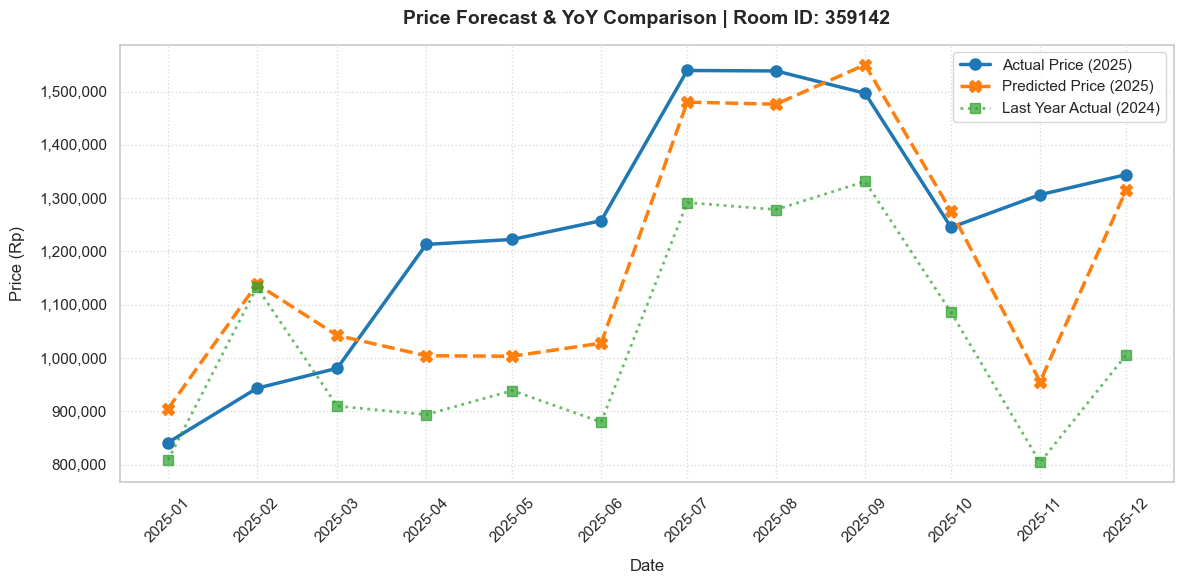

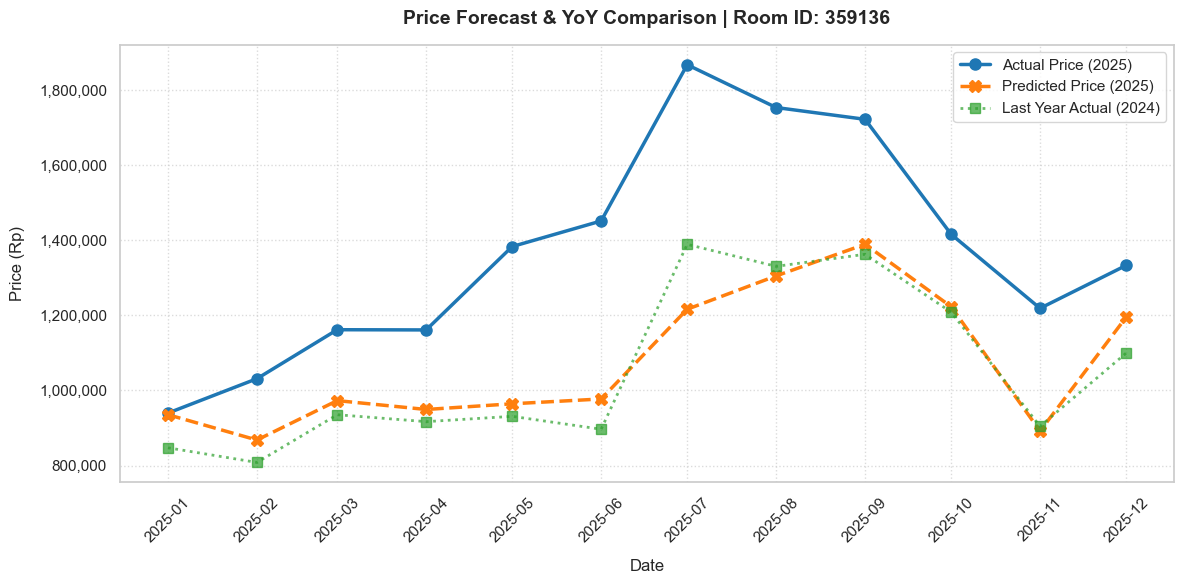

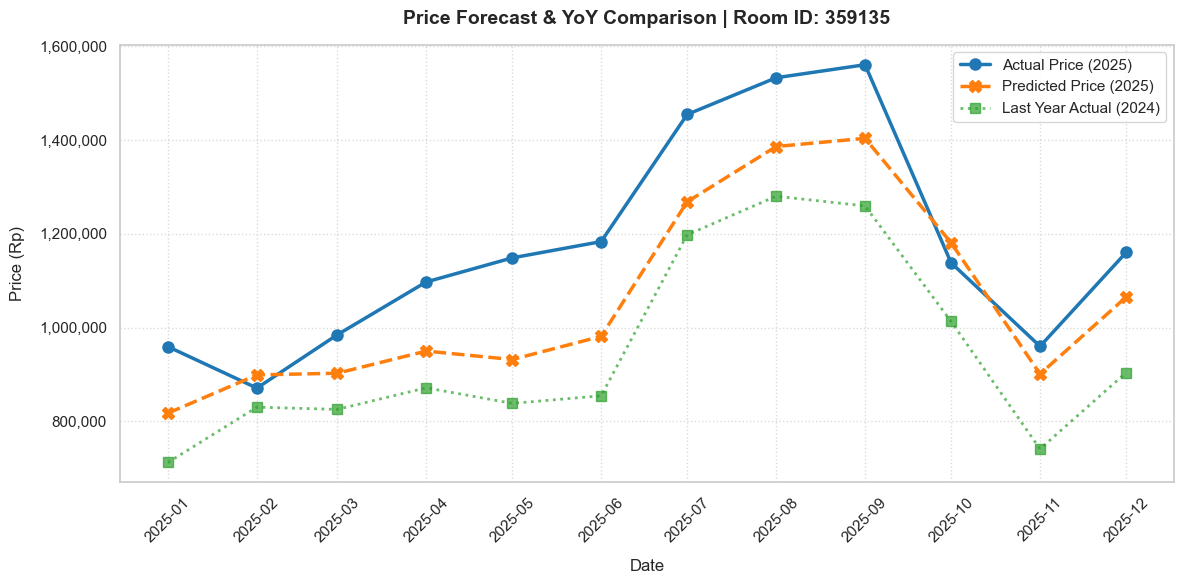

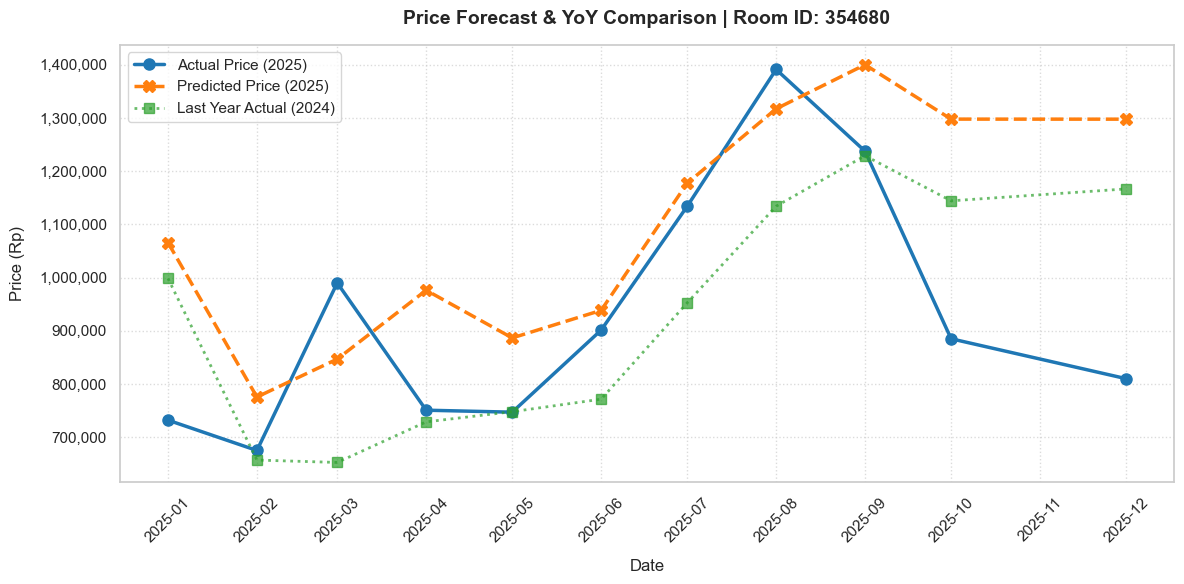

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import pandas as pd
import numpy as np

def plot_room_actual_vs_predicted(trained_models, room_ids, full_data):
    """
    Plots Actual, Predicted, and Last Year's Actual prices over time.
    Generates features dynamically per horizon to avoid LightGBM Feature Errors.
    """
    sns.set_theme(style="whitegrid")
    
    # ------------------------------------------------------------------
    # 1. SAFELY HANDLE DATES
    # ------------------------------------------------------------------
    df_master = full_data.copy()
    if 'date' not in df_master.columns:
        if pd.api.types.is_period_dtype(df_master['month_period']):
            df_master['date'] = df_master['month_period'].dt.to_timestamp()
        else:
            df_master['date'] = pd.to_datetime(df_master['month_period'])
    else:
        if pd.api.types.is_period_dtype(df_master['date']):
            df_master['date'] = df_master['date'].dt.to_timestamp()
        else:
            df_master['date'] = pd.to_datetime(df_master['date'])

    # Categorical columns used during training
    cat_cols = [
        "roomId", "propertyId", "room_cfg_room_type",
        "room_cfg_restriction_strategy", "room_cfg_overbooking_protection",
        "room_cfg_unit_allocation", "room_cfg_tier",
    ]

    # ------------------------------------------------------------------
    # 2. PLOTTING LOOP
    # ------------------------------------------------------------------
    for room_id in room_ids:
        dates = []
        actuals = []
        predictions = []
        last_year_actuals = []

        # Predict 2025 month by month (h=1 is Jan, h=12 is Dec)
        for h in range(1, 13):
            if h not in trained_models:
                continue
                
            model = trained_models[h]
            target_year = 2025
            target_month = h 
            
            try:
                # A. Generate the EXACT features this specific model expects
                step_data = advanced_hybrid_fe_direct(df_master, h=h)
                
                # B. Filter for our target prediction month and room
                mask = (
                    (step_data["date"].dt.year == target_year) & 
                    (step_data["date"].dt.month == target_month) & 
                    (step_data["roomId"] == room_id)
                )
                inference_df = step_data[mask].copy()
                
                if inference_df.empty:
                    continue
                    
                # C. Drop columns to match training X
                cols_to_drop = [
                    "price", "log_price", "target_diff", "target_pct",
                    "date", "month_period", f"log_price_lag_{h}", "log_price_lag_12", "id"
                ]
                X_infer = inference_df.drop(columns=[c for c in cols_to_drop if c in inference_df.columns], errors="ignore")
                
                good_lgbm_dtypes = ["number", "category", "bool"]
                X_infer = X_infer.select_dtypes(include=good_lgbm_dtypes).copy()
                
                # Ensure categories match
                for c in cat_cols:
                    if c in X_infer.columns:
                        X_infer[c] = X_infer[c].astype("category")

                # D. Predict and Reconstruct using the YoY anchor
                pred_diff = model.predict(X_infer)
                
                anchor_val = inference_df["price_lag_12"].values[0]
                actual_val = inference_df["price"].values[0]
                
                # Reverse the log1p transformation
                pred_price = np.expm1(np.log1p(anchor_val) + pred_diff)[0]
                
                # Save to lists for plotting
                dates.append(inference_df["date"].values[0])
                actuals.append(actual_val)
                predictions.append(pred_price)
                last_year_actuals.append(anchor_val)

            except Exception as e:
                # If it fails now, it will actually tell us WHY
                print(f"Error predicting Room {room_id} for Month {h}: {e}")

        # ------------------------------------------------------------------
        # 3. RENDER PLOT
        # ------------------------------------------------------------------
        if not dates:
            print(f"Skipping Room ID {room_id}: Could not generate predictions.")
            continue

        fig, ax = plt.subplots(figsize=(12, 6))
        
        ax.plot(dates, actuals, marker='o', label='Actual Price (2025)', color='#1f77b4', linewidth=2.5, markersize=8)
        ax.plot(dates, predictions, marker='X', label='Predicted Price (2025)', color='#ff7f0e', linestyle='--', linewidth=2.5, markersize=8)
        ax.plot(dates, last_year_actuals, marker='s', label='Last Year Actual (2024)', color='#2ca02c', linestyle=':', linewidth=2, markersize=7, alpha=0.7)

        ax.set_title(f"Price Forecast & YoY Comparison | Room ID: {room_id}", fontsize=14, fontweight='bold', pad=15)
        ax.set_xlabel("Date", fontsize=12, labelpad=10)
        ax.set_ylabel("Price (Rp)", fontsize=12, labelpad=10)
        
        ax.xaxis.set_major_locator(mdates.MonthLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        plt.xticks(rotation=45)
        
        ax.legend(fontsize=11)
        ax.grid(True, linestyle=':', alpha=0.7)
        ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
        
        plt.tight_layout()
        plt.show()

# ==========================================
# USAGE EXAMPLE (Notice it's much cleaner now!)
# ==========================================
rooms_to_plot = [359142, 359136, 359135, 354680]
# rooms_to_plot = [354683, 354680]

plot_room_actual_vs_predicted(
    trained_models=trained_models, 
    room_ids=rooms_to_plot,
    full_data=data 
)

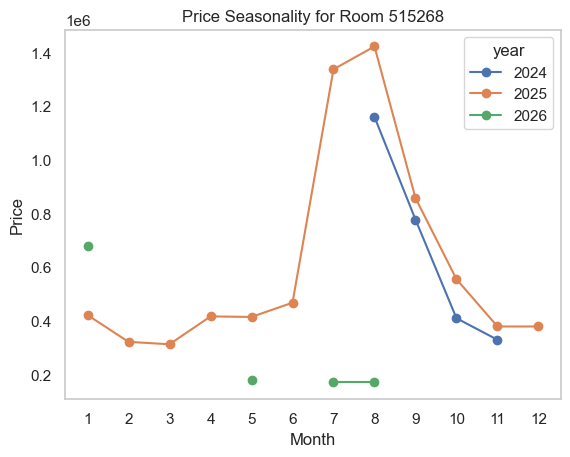

In [131]:
import matplotlib.pyplot as plt
import pandas as pd

# room_id_target = 354683
# room_id_target = 419296
# room_id_target = 370150
# room_id_target = 512299	
# room_id_target = 354683	
# room_id_target = 354680	
room_id_target = 515268
# 5	354683	Deluxe Double or Twin Room with Balcony	Mantra Gili	32.669917	207643.476947	48
# 2	354680

# 354683	
# 1	354680	
# 512299  # change this

subset = data.copy()
subset = subset[subset["roomId"] == room_id_target]

subset["month_period"] = pd.to_datetime(subset["month_period"])
# subset["month_period"] = (subset["month_period"])
subset["year"] = subset["month_period"].dt.year
subset["month"] = subset["month_period"].dt.month

pivot = subset.pivot(index="month", columns="year", values="price")

pivot.plot(marker="o")

plt.title(f"Price Seasonality for Room {room_id_target}")
plt.xlabel("Month")
plt.ylabel("Price")
plt.xticks(range(1, 13))
plt.grid()

plt.show()

In [ ]:
Property ID: 243134
  ⏳ Fetching year 2023... ✅ Dapat 9080 bookings.
  ⏳ Fetching year 2024... ✅ Dapat 12130 bookings.
  ⏳ Fetching year 2025... ✅ Dapat 11164

In [278]:
data[data['roomId'] == 354680][['date', 'price']].sort_values('date')

,date,price
91,2022-06-01,5.190000e+05
92,2022-07-01,6.570000e+05
93,2022-08-01,7.164583e+05
94,2022-09-01,6.726375e+05
95,2022-10-01,3.553333e+05
96,2022-11-01,6.480000e+05
97,2022-12-01,8.512500e+05
98,2023-01-01,7.275000e+05
99,2023-02-01,6.750000e+05
100,2023-03-01,7.425000e+05


In [337]:
import pandas as pd
import numpy as np

def predict_next_12_months(room_id, start_date, full_data, trained_models):
    """
    Given a starting date (origin), predicts the next 12 months for a specific room.
    Includes Smart Fallbacks for missing YoY anchors.
    """
    print(f"--- Forecasting 12 Months for Room {room_id} ---")
    print(f"Origin Date: {start_date}")
    
    # ------------------------------------------------------------------
    # 1. SAFELY HANDLE DATES
    # ------------------------------------------------------------------
    df_master = full_data.copy()
    if 'date' not in df_master.columns:
        if pd.api.types.is_period_dtype(df_master['month_period']):
            df_master['date'] = df_master['month_period'].dt.to_timestamp()
        else:
            df_master['date'] = pd.to_datetime(df_master['month_period'].astype(str))
    else:
        if pd.api.types.is_period_dtype(df_master['date']):
            df_master['date'] = df_master['date'].dt.to_timestamp()
        else:
            df_master['date'] = pd.to_datetime(df_master['date'])

    start_dt = pd.to_datetime(start_date)
    
    # ------------------------------------------------------------------
    # 2. AUTO-PAD FUTURE DATES (FIXED FORMATTING)
    # ------------------------------------------------------------------
    existing_dates = df_master[df_master['roomId'] == room_id]['date'].values
    target_dates = [start_dt + pd.DateOffset(months=h) for h in range(1, 13)]
    
    missing_dates = [d for d in target_dates if d not in existing_dates]
    
    if missing_dates:
        future_df = pd.DataFrame({'date': missing_dates, 'roomId': room_id})
        
        if 'month_period' in df_master.columns:
            if pd.api.types.is_period_dtype(df_master['month_period']):
                future_df['month_period'] = pd.Series(missing_dates).dt.to_period('M')
            else:
                # 🚨 THE FIX: Force the future dates into clean "YYYY-MM" strings
                future_df['month_period'] = [d.strftime('%Y-%m') for d in missing_dates]
                
        static_cols = ["propertyId", "room_cfg_room_type", "room_cfg_restriction_strategy", 
                       "room_cfg_overbooking_protection", "room_cfg_unit_allocation", "room_cfg_tier"]
        
        last_known_row = df_master[df_master['roomId'] == room_id].iloc[-1]
        for col in static_cols:
            if col in df_master.columns:
                future_df[col] = last_known_row[col]
                
        df_master = pd.concat([df_master, future_df], ignore_index=True)
        df_master = df_master.sort_values(['roomId', 'date']).reset_index(drop=True)

    cat_cols = [
        "roomId", "propertyId", "room_cfg_room_type",
        "room_cfg_restriction_strategy", "room_cfg_overbooking_protection",
        "room_cfg_unit_allocation", "room_cfg_tier",
    ]

    results = []

    # ------------------------------------------------------------------
    # 3. 12-STEP FORECASTING LOOP
    # ------------------------------------------------------------------
    for h in range(1, 13):
        if h not in trained_models:
            print(f"Skipping Month {h}: Model not found.")
            continue
            
        target_dt = start_dt + pd.DateOffset(months=h)
        model = trained_models[h]
        
        try:
            step_data = advanced_hybrid_fe_direct(df_master, h=h)
            
            mask = (step_data["date"] == target_dt) & (step_data["roomId"] == room_id)
            inference_df = step_data[mask].copy()
            
            if inference_df.empty:
                print(f"Month {h} ({target_dt.strftime('%Y-%m')}): Failed to build features.")
                continue
                
            cols_to_drop = [
                "price", "log_price", "target_diff", "target_pct",
                "date", "month_period", f"log_price_lag_{h}", "log_price_lag_12", "id"
            ]
            X_infer = inference_df.drop(columns=[c for c in cols_to_drop if c in inference_df.columns], errors="ignore")
            
            good_lgbm_dtypes = ["number", "category", "bool"]
            X_infer = X_infer.select_dtypes(include=good_lgbm_dtypes).copy()
            
            for c in cat_cols:
                if c in X_infer.columns:
                    X_infer[c] = X_infer[c].astype("category")

            # ----------------------------------------------------------
            # SMART FALLBACK ANCHOR LOGIC
            # ----------------------------------------------------------
            # We use dynamic_anchor_price now instead of strictly price_lag_12
            anchor_val = inference_df["dynamic_anchor_price"].values[0] if "dynamic_anchor_price" in inference_df.columns else np.nan
            baseline_note = f"Dynamic Anchor ({inference_df['anchor_age_months'].values[0]} months old)" if "anchor_age_months" in inference_df.columns else "Unknown Anchor"

            if pd.isna(anchor_val):
                hist_same_month = df_master[
                    (df_master['roomId'] == room_id) & 
                    (df_master['date'].dt.month == target_dt.month) &
                    (df_master['date'] < target_dt) & 
                    (df_master['price'].notna())
                ].sort_values('date')
                
                if not hist_same_month.empty:
                    anchor_val = hist_same_month['price'].values[-1]
                    fallback_year = hist_same_month['date'].dt.year.values[-1]
                    baseline_note = f"Manual Fallback: {fallback_year}"
                else:
                    all_hist = df_master[
                        (df_master['roomId'] == room_id) & 
                        (df_master['date'] < target_dt) &
                        (df_master['price'].notna())
                    ].sort_values('date')
                    
                    if not all_hist.empty:
                        anchor_val = all_hist['price'].values[-1]
                        baseline_note = "Manual Fallback: Last Known Price"
                    else:
                        print(f"Month {h} ({target_dt.strftime('%Y-%m')}): Room has ZERO historical data. Skipping.")
                        continue
                
                if 'dynamic_anchor_price' in X_infer.columns:
                    X_infer['dynamic_anchor_price'] = anchor_val

            # D. Predict
            pred_diff = model.predict(X_infer)
            
            # E. Reconstruct
            pred_price = np.expm1(np.log1p(anchor_val) + pred_diff)[0]
            
            if "price" in inference_df.columns and not pd.isna(inference_df["price"].values[0]):
                actual_val = inference_df["price"].values[0]
            else:
                actual_val = np.nan
            
            results.append({
                "Horizon": f"+{h} Month",
                "Target Date": target_dt.strftime("%Y-%m"),
                "Predicted Price": f"Rp {pred_price:,.0f}",
                "Baseline Used": f"Rp {anchor_val:,.0f}",
                "Baseline Note": baseline_note,
                "Actual Price": f"Rp {actual_val:,.0f}" if pd.notna(actual_val) else "-"
            })

        except Exception as e:
            print(f"Error on Horizon {h}: {e}")

    # ------------------------------------------------------------------
    # 4. PRINT RESULTS
    # ------------------------------------------------------------------
    result_df = pd.DataFrame(results)
    
    if not result_df.empty:
        display(result_df.style.set_properties(**{'text-align': 'right'}))
    else:
        print("No predictions could be generated.")
        
    return result_df
# ==========================================
# HOW TO USE IT
# ==========================================
# Example: Predict the entirety of 2025 by setting the origin to Dec 2024.
# (This means h=1 is Jan 2025, h=2 is Feb 2025... up to h=12 which is Dec 2025)

predicted_df = predict_next_12_months(
    # room_id=359142,
    # room_id=359135,
    # room_id=359142,
    # room_id=354683,	# mantra gili
	room_id=354682,
    start_date='2026-01-01', 
    full_data=data, 
    trained_models=final_production_models
)

--- Forecasting 12 Months for Room 354682 ---
Origin Date: 2026-01-01


,Horizon,Target Date,Predicted Price,Baseline Used,Baseline Note,Actual Price
0,+1 Month,2026-02,"Rp 574,191","Rp 647,163",Dynamic Anchor (12 months old),"Rp 540,000"
1,+2 Month,2026-03,"Rp 644,553","Rp 699,261",Dynamic Anchor (12 months old),"Rp 855,000"
2,+3 Month,2026-04,"Rp 746,842","Rp 733,670",Dynamic Anchor (12 months old),"Rp 697,500"
3,+4 Month,2026-05,"Rp 851,183","Rp 754,849",Dynamic Anchor (12 months old),"Rp 697,500"
4,+5 Month,2026-06,"Rp 838,766","Rp 800,473",Dynamic Anchor (12 months old),"Rp 697,500"
5,+6 Month,2026-07,"Rp 1,334,850","Rp 1,116,136",Dynamic Anchor (12 months old),"Rp 1,125,000"
6,+7 Month,2026-08,"Rp 1,537,707","Rp 1,281,226",Dynamic Anchor (12 months old),"Rp 1,345,000"
7,+8 Month,2026-09,"Rp 1,280,499","Rp 1,187,381",Dynamic Anchor (12 months old),"Rp 1,345,000"
8,+9 Month,2026-10,"Rp 856,225","Rp 771,983",Dynamic Anchor (12 months old),"Rp 1,345,000"
9,+10 Month,2026-11,"Rp 749,569","Rp 630,000",Dynamic Anchor (12 months old),"Rp 1,345,000"


In [291]:
data[data['roomId'] == 359142][['month_period','price']]

,month_period,price
440,2022-06,6.981250e+05
441,2022-07,6.981250e+05
442,2022-08,6.941795e+05
443,2022-09,6.369283e+05
444,2022-10,6.369189e+05
445,2022-11,4.174272e+05
446,2022-12,5.216373e+05
447,2023-01,5.948644e+05
448,2023-02,8.621782e+05
449,2023-03,6.501247e+05


In [108]:
pd.to_datetime(data["month_period"])

TypeError: Passing PeriodDtype data is invalid. Use `data.to_timestamp()` instead

In [290]:
def check_room_gaps(df):
    """
    Analyzes missing price data per roomId after the grid is expanded.
    """
    # 1. Ensure we are looking at the expanded grid but BEFORE filling prices
    # If you've already filled them, this count will be 0.
    
    # Calculate stats per room
    gap_stats = df.groupby('roomId').agg(
        total_months=('date', 'count'),
        missing_months=('price', lambda x: x.isna().sum()),
        first_date=('date', 'min'),
        last_date=('date', 'max')
    )
    
    # Calculate percentage missing
    gap_stats['percent_missing'] = (gap_stats['missing_months'] / gap_stats['total_months']) * 100
    
    # Sort by the most "broken" rooms
    gap_stats = gap_stats.sort_values('percent_missing', ascending=False)
    
    # Summary Info
    print(f"--- Global Data Integrity Report ---")
    print(f"Total Unique Rooms: {len(gap_stats)}")
    print(f"Average Missing Data: {gap_stats['percent_missing'].mean():.2f}%")
    print(f"Rooms with >50% Missing: {len(gap_stats[gap_stats['percent_missing'] > 50])}")
    print("-" * 35)
    
    # Display the top 20 rooms with the most gaps
    display(gap_stats.head(20).style.format({'percent_missing': '{:.1f}%'}))
    
    return gap_stats

# ==========================================
# USAGE
# ==========================================
# 1. Create the grid (Injects NaNs into the gaps)
data_with_gaps = create_continuous_calendar_grid(data)

# 2. Check the report BEFORE you fill the prices
room_report = check_room_gaps(data_with_gaps)

# 3. Optional: Drop rooms that are "Too Broken"
# If a room is 90% missing, the ffill() will just be a flat line and confuse the model.
bad_rooms = room_report[room_report['percent_missing'] > 70].index
# data_with_gaps = data_with_gaps[~data_with_gaps['roomId'].isin(bad_rooms)]

Building continuous calendar grid...
Grid built. Expanded from 2124 to 2200 rows to fill chronological gaps.
--- Global Data Integrity Report ---
Total Unique Rooms: 40
Average Missing Data: 3.45%
Rooms with >50% Missing: 0
-----------------------------------


,total_months,missing_months,first_date,last_date,percent_missing
roomId,,,,,
512299,55,19,2022-06-01 00:00:00,2026-12-01 00:00:00,34.5%
512300,55,19,2022-06-01 00:00:00,2026-12-01 00:00:00,34.5%
515268,55,19,2022-06-01 00:00:00,2026-12-01 00:00:00,34.5%
512298,55,19,2022-06-01 00:00:00,2026-12-01 00:00:00,34.5%
350455,55,0,2022-06-01 00:00:00,2026-12-01 00:00:00,0.0%
350464,55,0,2022-06-01 00:00:00,2026-12-01 00:00:00,0.0%
354680,55,0,2022-06-01 00:00:00,2026-12-01 00:00:00,0.0%
354681,55,0,2022-06-01 00:00:00,2026-12-01 00:00:00,0.0%
359136,55,0,2022-06-01 00:00:00,2026-12-01 00:00:00,0.0%


In [162]:
data

,month_period,id,masterId,propertyId,roomId,numChild,price,commission,range_booking_arrival,num_of_nights,status_confirmed,status_new,subStatus_noShow,subStatus_nonPayment,subStatus_none,subStatus_walkin,title_Honeymoon_decor,title_RO,title_Teman_kim_kasih_breakfast,title_Twin_bed,arrivalTime_16_3,arrivalTime_16_30,arrivalTime__,voucher_geniuscm,groupNote_Room_Only_,custom1_Paid_OTA,custom1_Paid_by_OTA_Auto_Adjusted,referer_Booking_com,refererEditable_Booking_com,reference_45867993_marie,reference_E5593226_ANNA_HUBER,reference_EJ4657377_,reference_PAL643451_LUCAS,reference_PAM228132,reference_YB7740043,channel_booking,apiSource_Booking_com,allowChannelUpdate_all,allowAutoAction_disable,allowAutoAction_enable,allowReview_default,allowCancellation__type_propertyDefault_,cancelTime_2024_08_05T03_15_10Z,year,month,year_month,total_capacity_nights,used_room_nights,leftover_rooms,cal_days_covered,cal_numAvail_mean,cal_numAvail_min,cal_numAvail_max,cal_numAvail_std,cal_numAvail_zero_days,cal_numAvail_low_days,cal_minStay_mean,cal_minStay_max,cal_minStay_restrict_days,cal_maxStay_mean,cal_multiplier_mean,cal_multiplier_max,cal_override_days,cal_soldout_rate,cal_low_avail_rate,cal_restrict_rate,cal_override_rate,prop_latitude,prop_longitude,prop_checkin_start_min,prop_checkin_end_min,prop_checkout_end_min,prop_booking_cutoff_hour,prop_vat_rate,prop_feature_codes_count,prop_group_keywords_count,prop_type_bedAndBreakfast,prop_type_bungalow,prop_type_guesthouse,prop_type_hotel,prop_type_resort,prop_type_villa,prop_country_ID,ch_channel_count,ch_enabled_ratio,ch_publish_ratio,ch_connect_inventory_ratio,ch_connect_limited_ratio,ch_price_per_day_ratio,review_count,avg_review_score,avg_facilities_score,avg_comfort_score,avg_staff_score,avg_value_score,avg_clean_score,avg_location_score,tfidf_beach,tfidf_clean,tfidf_da,tfidf_de,tfidf_der,tfidf_die,tfidf_el,tfidf_en,tfidf_est,tfidf_et,tfidf_friendly,tfidf_good,tfidf_great,tfidf_hotel,tfidf_la,tfidf_le,tfidf_location,tfidf_muy,tfidf_nice,tfidf_place,tfidf_pool,tfidf_que,tfidf_room,tfidf_sehr,tfidf_staff,tfidf_stay,tfidf_super,tfidf_trs,tfidf_un,tfidf_und,qty,room_cfg_qty_raw,room_cfg_min_price,room_cfg_min_stay,room_cfg_max_stay,room_cfg_max_people,room_cfg_max_adult,room_cfg_max_children,room_cfg_tax_percentage,room_cfg_tax_person,room_cfg_rack_rate,room_cfg_cleaning_fee,room_cfg_security_deposit,room_cfg_sell_priority,room_cfg_room_size,room_cfg_block_after_checkout_days,room_cfg_control_priority,room_cfg_include_in_reports,room_cfg_units_count,room_cfg_has_unallocated_unit,room_cfg_feature_count,room_cfg_roomType_bungalow,room_cfg_roomType_double,room_cfg_roomType_family,room_cfg_roomType_quadruple,room_cfg_roomType_single,room_cfg_roomType_triple,room_cfg_roomType_twin,room_cfg_roomType_twindouble,room_cfg_roomType_villa,room_cfg_restrictionStrategy_staythrough,room_cfg_overbookingProtection_property,room_cfg_overbookingProtection_room,room_cfg_unitAllocation_perbooking,room_fc_airport_shuttle,room_fc_air_conditioning,room_fc_baggage_storage,room_fc_balcony,room_fc_bar,room_fc_bathrobe,room_fc_bathroom,room_fc_bath_or_shower,room_fc_bath_shower,room_fc_bath_toilet,room_fc_beach,room_fc_beach_front,room_fc_beach_view,room_fc_bedroom,room_fc_bed_double,room_fc_bed_single,room_fc_bicycle,room_fc_breakfast_included,room_fc_breakfast_in_room,room_fc_breakfast_possible,room_fc_cable,room_fc_car_available,room_fc_cleaning_included,room_fc_cleaning_possible,room_fc_closets_in_room,room_fc_coffee_maker,room_fc_cycling,room_fc_deck_patio_uncovered,room_fc_desk,room_fc_dining_area,room_fc_dining_room_seats,room_fc_garden,room_fc_hair_dryer,room_fc_hangers,room_fc_iron,room_fc_kettle,room_fc_laptop_friendly,room_fc_linens,room_fc_luxory_linen,room_fc_minibar,room_fc_mountain_biking,room_fc_private_bathroom,room_fc_reception_24_hour,room_fc_refrigerator,room_fc_restaurant,room_fc_room_soundproofed,room_fc_safe,room_fc_satellite,room_fc_scuba_or_snorkeling,room_fc_separate_toilet_area,room_fc_shampoo,room

In [ ]:
Mean Holdout MAPE across horizons: 0.2303 (23.03%)
Mean Holdout MAE across horizons : Rp 128,831.87

In [252]:
import numpy as np

def predict_for_room_month(
    test_data,
    x_test_full,
    trained_models,
    room_id,
    year,
    month,
    model_index=7
):
    lag = model_index
    # Sort to ensure lag is correct
    df = test_data.sort_values(["roomId", "date"]).copy()
    
    # Create lag feature
    lag_col = f"price_lag_{lag}"
    df[lag_col] = df.groupby("roomId")["price"].shift(lag)
    
    # Filter mask
    mask = (
        (df["roomId"] == room_id) &
        (df["year"] == year) &
        (df["month"] == month)
    )
    
    # Select data
    X_selected = x_test_full[mask]
    baseline_selected = df.loc[mask, lag_col].values
    
    # Predict diff
    pred_diff = trained_models[model_index].predict(X_selected)
    
    # Reconstruct final prediction
    final_preds = np.expm1(
        np.log1p(baseline_selected) + pred_diff
    )
    
    return final_preds

preds = predict_for_room_month(
    test_data=test_data,
    x_test_full=x_test_full,
    trained_models=final_production_models,
    # room_id=359136,
    # room_id=359135,
    room_id=359142,
    year=2025,
    month=12,
    model_index=6
)

print(preds)

LightGBMError: The number of features in data (305) is not the same as it was in training data (309).
You can set ``predict_disable_shape_check=true`` to discard this error, but please be aware what you are doing.

In [ ]:
359136 359135 359142

In [37]:
test_data = test_data.sort_values(["roomId", "date"]).copy()

test_data["price_lag_6"] = (
    test_data.groupby("roomId")["price"]
    .shift(6)
)
mask = (
    # (test_data['roomId'] == 359136) &
    # (test_data['roomId'] == 359135) &
    (test_data['roomId'] == 359142) &
    (test_data['year'] == 2025) &
    (test_data['month'] == 12)
)

X_selected = x_test_full[mask]
baseline_selected = test_data.loc[mask, 'price_lag_6'].values

pred_test_diff = trained_models[6].predict(X_selected)

final_test_predictions = np.expm1(
    np.log1p(baseline_selected) + pred_test_diff
)

final_test_predictions

array([1470124.58024593])

In [216]:
baseline_selected

array([nan])

In [214]:
X_selected

,propertyId,roomId,year,month,total_capacity_nights,quarter,season_strength,is_peak_season,is_eid_month,is_major_holiday_month,price_lag_10,price_lag_11,price_lag_12,price_lag_15,price_lag_21,price_roll_mean_3,price_roll_std_3,price_roll_max_3,price_roll_min_3,price_roll_mean_6,price_roll_std_6,price_roll_max_6,price_roll_min_6,price_roll_mean_12,price_roll_std_12,price_roll_max_12,price_roll_min_12,price_diff_1,price_diff_12,price_growth_1,price_ema_3,used_room_nights_lag_10,used_room_nights_lag_11,used_room_nights_lag_21,used_room_nights_roll_mean_3,leftover_rooms_lag_10,leftover_rooms_lag_11,leftover_rooms_lag_21,leftover_rooms_roll_mean_3,range_booking_arrival_lag_10,range_booking_arrival_lag_11,range_booking_arrival_lag_21,range_booking_arrival_roll_mean_3,num_of_nights_lag_10,num_of_nights_lag_11,num_of_nights_lag_21,num_of_nights_roll_mean_3,commission_lag_10,commission_lag_11,commission_lag_21,commission_roll_mean_3,numChild_lag_10,numChild_lag_11,numChild_lag_21,numChild_roll_mean_3,occupancy_trend,price_to_mean_ratio,price_vs_property_avg,price_zscore_property,occupancy_price_interaction,trend_3_vs_12,trend_slope,price_vs_roll_mean_6,price_cv_6,is_volatile_room,is_spike,season_price_interaction,peak_price_interaction,occupancy_season_interaction,avg_location_score_lag_10,allowReview_default_lag_10,tfidf_la_lag_10,tfidf_un_lag_10,allowAutoAction_enable_lag_10,reference_EJ4657377__lag_10,tfidf_der_lag_10,channel_booking_lag_10,custom1_Paid_by_OTA_Auto_Adjusted_lag_10,subStatus_nonPayment_lag_10,status_new_lag_10,tfidf_le_lag_10,allowChannelUpdate_all_lag_10,tfidf_da_lag_10,tfidf_stay_lag_10,tfidf_location_lag_10,tfidf_nice_lag_10,tfidf_pool_lag_10,tfidf_place_lag_10,referer_Booking_com_lag_10,subStatus_none_lag_10,tfidf_est_lag_10,tfidf_super_lag_10,tfidf_die_lag_10,subStatus_walkin_lag_10,reference_E5593226_ANNA_HUBER_lag_10,tfidf_clean_lag_10,title_Twin_bed_lag_10,tfidf_room_lag_10,avg_facilities_score_lag_10,voucher_geniuscm_lag_10,arrivalTime_16_30_lag_10,tfidf_great_lag_10,avg_clean_score_lag_10,groupNote_Room_Only__lag_10,custom1_Paid_OTA_lag_10,avg_comfort_score_lag_10,allowCancellation__type_propertyDefault__lag_10,tfidf_en_lag_10,title_Honeymoon_decor_lag_10,tfidf_friendly_lag_10,apiSource_Booking_com_lag_10,arrivalTime___lag_10,review_count_lag_10,tfidf_good_lag_10,tfidf_de_lag_10,tfidf_und_lag_10,tfidf_staff_lag_10,reference_PAL643451_LUCAS_lag_10,title_RO_lag_10,tfidf_que_lag_10,reference_PAM228132_lag_10,allowAutoAction_disable_lag_10,reference_YB7740043_lag_10,tfidf_el_lag_10,subStatus_noShow_lag_10,tfidf_hotel_lag_10,tfidf_muy_lag_10,tfidf_et_lag_10,tfidf_beach_lag_10,title_Teman_kim_kasih_breakfast_lag_10,tfidf_trs_lag_10,avg_staff_score_lag_10,avg_review_score_lag_10,cancelTime_2024_08_05T03_15_10Z_lag_10,reference_45867993_marie_lag_10,refererEditable_Booking_com_lag_10,tfidf_sehr_lag_10,avg_value_score_lag_10,status_confirmed_lag_10,month_sin,month_cos,price_vs_trend_12,trend_strength,month_price_interaction,month_sin_price,month_cos_price,log_price_roll_std_6,log_price_roll_std_12,year_trend
22,163277.0,359136.0,2025,8,124,3,2,1,0,0,1.208834e+06,1.362743e+06,1.330573e+06,931164.305556,739081.635143,1.300717e+06,81182.451621,1.362743e+06,1.208834e+06,1.186567e+06,220244.927323,1389263.0,896823.333333,1.018265e+06,235158.76949,1389263.0,739081.635143,-153909.69697,469752.001221,-0.112941,1.254936e+06,117.0,116.0,107.0,118.666667,7.0,4.0,13.0,4.0,111.242424,131.555556,91.88,121.753173,3.393939,3.444444,3.68,3.202538,730012.757576,847686.592593,471945.36,742121.86886,0.090909,0.074074,0.12,0.166105,1.0,1.187151,1.203632,0.694946,1.414335e+08,1.277386,22266.919548,1.018766,0.185615,1,0,2.417667e+06,1.208834e+06,1.0,9.772727,33.0,0.152294,0.038988,33.0,0.0,0.057446,33.0,0.0,0.0,0.0,0.04892,33.0,0.03482,0.028994,0.100891,0.0,0.007593,0.0,33.0,33.0,0.012202,0.045284,0.025801,0.0,0.0,0.029692,0.0,0.031613,8.977273,33.0,33.0,0.029408,9.204545,33.0,33.0,9.545455,33.0,0.075661,0.0,0.051735,33.0,0.0,0.0,0.031343

In [ ]:
filt_room = x_test_full['roomId'] == 359135
filt_year = x_test_full['year'] == 2026
filt_month = x_test_full['month'] == 5
x_test_full[filt_room & filt_month & filt_year]

,propertyId,roomId,year,month,total_capacity_nights,quarter,season_strength,is_peak_season,is_eid_month,is_major_holiday_month,price_lag_10,price_lag_11,price_lag_12,price_lag_15,price_lag_21,price_roll_mean_3,price_roll_std_3,price_roll_max_3,price_roll_min_3,price_roll_mean_6,price_roll_std_6,price_roll_max_6,price_roll_min_6,price_roll_mean_12,price_roll_std_12,price_roll_max_12,price_roll_min_12,price_diff_1,price_diff_12,price_growth_1,price_ema_3,used_room_nights_lag_10,used_room_nights_lag_11,used_room_nights_lag_21,used_room_nights_roll_mean_3,leftover_rooms_lag_10,leftover_rooms_lag_11,leftover_rooms_lag_21,leftover_rooms_roll_mean_3,range_booking_arrival_lag_10,range_booking_arrival_lag_11,range_booking_arrival_lag_21,range_booking_arrival_roll_mean_3,num_of_nights_lag_10,num_of_nights_lag_11,num_of_nights_lag_21,num_of_nights_roll_mean_3,commission_lag_10,commission_lag_11,commission_lag_21,commission_roll_mean_3,numChild_lag_10,numChild_lag_11,numChild_lag_21,numChild_roll_mean_3,occupancy_trend,price_to_mean_ratio,price_vs_property_avg,price_zscore_property,occupancy_price_interaction,trend_3_vs_12,trend_slope,price_vs_roll_mean_6,price_cv_6,is_volatile_room,is_spike,season_price_interaction,peak_price_interaction,occupancy_season_interaction,avg_location_score_lag_10,allowReview_default_lag_10,tfidf_la_lag_10,tfidf_un_lag_10,allowAutoAction_enable_lag_10,reference_EJ4657377__lag_10,tfidf_der_lag_10,channel_booking_lag_10,custom1_Paid_by_OTA_Auto_Adjusted_lag_10,subStatus_nonPayment_lag_10,status_new_lag_10,tfidf_le_lag_10,allowChannelUpdate_all_lag_10,tfidf_da_lag_10,tfidf_stay_lag_10,tfidf_location_lag_10,tfidf_nice_lag_10,tfidf_pool_lag_10,tfidf_place_lag_10,referer_Booking_com_lag_10,subStatus_none_lag_10,tfidf_est_lag_10,tfidf_super_lag_10,tfidf_die_lag_10,subStatus_walkin_lag_10,reference_E5593226_ANNA_HUBER_lag_10,tfidf_clean_lag_10,title_Twin_bed_lag_10,tfidf_room_lag_10,avg_facilities_score_lag_10,voucher_geniuscm_lag_10,arrivalTime_16_30_lag_10,tfidf_great_lag_10,avg_clean_score_lag_10,groupNote_Room_Only__lag_10,custom1_Paid_OTA_lag_10,avg_comfort_score_lag_10,allowCancellation__type_propertyDefault__lag_10,tfidf_en_lag_10,title_Honeymoon_decor_lag_10,tfidf_friendly_lag_10,apiSource_Booking_com_lag_10,arrivalTime___lag_10,review_count_lag_10,tfidf_good_lag_10,tfidf_de_lag_10,tfidf_und_lag_10,tfidf_staff_lag_10,reference_PAL643451_LUCAS_lag_10,title_RO_lag_10,tfidf_que_lag_10,reference_PAM228132_lag_10,allowAutoAction_disable_lag_10,reference_YB7740043_lag_10,tfidf_el_lag_10,subStatus_noShow_lag_10,tfidf_hotel_lag_10,tfidf_muy_lag_10,tfidf_et_lag_10,tfidf_beach_lag_10,title_Teman_kim_kasih_breakfast_lag_10,tfidf_trs_lag_10,avg_staff_score_lag_10,avg_review_score_lag_10,cancelTime_2024_08_05T03_15_10Z_lag_10,reference_45867993_marie_lag_10,refererEditable_Booking_com_lag_10,tfidf_sehr_lag_10,avg_value_score_lag_10,status_confirmed_lag_10,month_sin,month_cos,price_vs_trend_12,trend_strength,month_price_interaction,month_sin_price,month_cos_price,log_price_roll_std_6,log_price_roll_std_12,year_trend
50,163277.0,359142.0,2026,5,310,2,1,0,0,0,1.539437e+06,1.257685e+06,1.222580e+06,943391.709184,1.278525e+06,1.339901e+06,173692.553253,1.539437e+06,1.222580e+06,1.192875e+06,215757.560646,1.539437e+06,943391.709184,1.125374e+06,218568.410247,1.539437e+06,804287.888776,281752.145931,260911.44817,0.224024,1.372548e+06,305.0,263.0,312.0,276.0,5.0,37.0,-2.0,30.666667,141.071429,73.970588,138.631579,89.194333,3.642857,3.352941,3.276316,3.222643,1.037131e+06,857696.058824,723469.039474,850483.237875,0.528571,0.191176,0.447368,0.310954,42.0,1.367934,1.532813,1.818357,4.695282e+08,1.190627,346562.319325,1.290527,0.180872,1,0,1.539437e+06,0.0,0.0,9.772727,70.0,0.152294,0.038988,70.0,0.0,0.057446,70.0,0.0,0.0,0.0,0.04892,70.0,0.03482,0.028994,0.100891,0.0,0.007593,0.0,70.0,70.0,0.012202,0.045284,0.025801,0.0,0.0,0.029692,0.0,0.031613,8.977273,70.0,70.0,0.029408,9.204545,70.0,70.0,9.545455,70.0,0.075661,0.0,0.051735,70.0,0

In [137]:
final_model.predict(x_test_full)

array([ 0.28455383,  0.18022226, -0.02987059, -0.0173718 ,  0.06977584,
        0.06910901,  0.17693678,  0.14399862,  0.18794647, -0.02933851,
       -0.1272426 ,  0.18739402,  0.04329553,  0.17474131,  0.13593363,
        0.17126423,  0.19274042,  0.03240215,  0.22655749,  0.20306334,
        0.15213975,  0.2328074 ,  0.23132553,  0.04757526,  0.05576755,
        0.22165781, -0.00419445, -0.06804376,  0.25219548,  0.21165028,
        0.18521155,  0.27435337,  0.20158833,  0.24648512,  0.09797842,
        0.17468845,  0.11569778, -0.0398098 , -0.03437158, -0.09577804,
        0.08878486,  0.16319703,  0.2070164 ,  0.12958843,  0.16749446,
        0.22911018,  0.1946344 ,  0.23590488,  0.00157933,  0.23538787,
        0.17216096,  0.1116792 ,  0.00793398,  0.02439255,  0.16884614,
        0.17298186,  0.16655468,  0.23210485,  0.15920129,  0.22405005,
        0.10554205,  0.07936019,  0.12885469,  0.1149995 ,  0.11171344,
        0.16958636,  0.18681891, -0.05324634,  0.03757646, -0.06

In [ ]:
Mean Holdout MAPE across horizons: 0.2347 (23.47%)
Mean Holdout MAE across horizons : Rp 130,458.87

In [ ]:
# Pa
Mean Holdout MAPE across horizons: 0.2358 (23.58%)
Mean Holdout MAE across horizons : Rp 131,044.69

In [ ]:
Mean Holdout MAPE across horizons: 0.2362 (23.62%)
Mean Holdout MAE across horizons : Rp 131,312.78

In [ ]:
🔹 Mean Holdout MAPE across 12 months : 0.2378 (23.78%)
🔹 Mean Holdout MAE across 12 months  : Rp 136,079.21

In [ ]:
🔹 Mean Holdout MAPE across 12 months : 0.2384 (23.84%)
🔹 Mean Holdout MAE across 12 months  : Rp 147,186.31

In [ ]:
163277